# M2 — Selección del universo de ETFs y construcción de inputs para optimización

**TFM — Roboadvisor personalizado para el inversor retail**
**Módulo M2 · Selección de universo y EDA cuantitativa**

---

## 0. Cabecera y objetivos

### Propósito
Este notebook construye el **universo definitivo de 9 ETFs** que alimentará el módulo de optimización de cartera (M3). Partimos de 30 candidatos UCITS preseleccionados por categoría (RF gobierno, RF corporativa, RV desarrollados, RV emergentes, sectoriales, alternativos) y aplicamos un proceso reproducible de:

1. Descarga y limpieza de precios ajustados desde 2010.
2. Análisis univariado (retornos, volatilidad, distribución).
3. Análisis multivariado (correlaciones con clustering jerárquico).
4. **Score multivariante 0–100** que combina ajuste al perfil, Sharpe, calidad de datos y poder diversificador.
5. Selección automática de los **3 mejores ETFs por perfil** (conservador / moderado / agresivo).
6. Construcción de los inputs para M3: matriz de retornos, vector μ, covarianza Ledoit-Wolf.

### Conexión con otros módulos del TFM
- **Input:** universo curado de 30 ETFs (Fase 0) + umbrales de volatilidad por perfil definidos en M1.
- **Output:** tres artefactos persistidos en disco (`returns_selected.parquet`, `mu_expected_returns.csv`, `cov_matrix_lw.npy`) y un `dict` `selected_etfs` con la justificación de cada elección.
- **Trazabilidad:** el score de cada ETF queda registrado para defender en la memoria por qué entra y por qué se descarta.

### Librerías necesarias
```bash
pip install yfinance pandas numpy scipy scikit-learn matplotlib seaborn pyarrow
```

> **Nota metodológica.** No se usa QuantStats en este notebook (se reserva para el backtesting walk-forward de M4). El Sharpe ratio se calcula como `(retorno_anual − 0.02) / vol_anual`, asumiendo una tasa libre de riesgo del 2% anual coherente con el promedio del Bund alemán a 10 años en el período de estudio.

In [1]:
# --- roboadvisor_paths bootstrap (auto-inserted) ---
import sys
from pathlib import Path as _P

_repo = _P.cwd().resolve()
while _repo != _repo.parent and not (_repo / "src" / "roboadvisor_paths.py").exists():
    _repo = _repo.parent
_src = _repo / "src"
if str(_src) not in sys.path:
    sys.path.insert(0, str(_src))

import roboadvisor_paths as PATHS  # noqa: E402
PATHS.ensure_dirs()


In [2]:
!pip install yfinance pandas numpy scipy scikit-learn matplotlib seaborn pyarrow


Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: C:\Users\juanl\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [3]:
# Imports y configuración global
import logging
import warnings
from pathlib import Path
from typing import Optional

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import yfinance as yf
from scipy import stats as sp_stats
from scipy.cluster.hierarchy import linkage, leaves_list
from scipy.spatial.distance import squareform
from sklearn.covariance import LedoitWolf

warnings.filterwarnings('ignore')
np.random.seed(42)

# Logging básico (info en consola, sin timestamps verbosos)
logging.basicConfig(
    level=logging.INFO,
    format='[%(levelname)s] %(message)s',
    force=True,
)
log = logging.getLogger('M2')

# Estilo gráfico
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['axes.titlesize'] = 12
plt.rcParams['axes.labelsize'] = 10
pd.set_option('display.float_format', lambda x: f'{x:,.4f}')

# Rutas
DATA_DIR = PATHS.M2_OUTPUTS_DIR  # outputs go here; raw cache uses PATHS.ETF_PRICES_RAW

# Constantes del proyecto
START_DATE = '2010-01-01'
TRADING_DAYS = 252
RISK_FREE_RATE = 0.02   # tasa libre de riesgo anual asumida (Bund 10y promedio)

# Umbrales de volatilidad anual por perfil de riesgo (definidos por M1)
VOL_THRESHOLDS = {'Conservador': 0.06, 'Moderado': 0.15, 'Agresivo': 0.25}

# Centro del rango de cada perfil (para penalizar desviaciones en ambos sentidos)
VOL_CENTERS = {'Conservador': 0.04, 'Moderado': 0.115, 'Agresivo': 0.20}

PERFIL_COLORS = {'Conservador': '#2E86AB', 'Moderado': '#F18F01', 'Agresivo': '#C73E1D'}

log.info('Configuración cargada — semilla=42, rf=%.1f%%, períodos=%d', RISK_FREE_RATE * 100, TRADING_DAYS)


[INFO] Configuración cargada — semilla=42, rf=2.0%, períodos=252


In [4]:
# Universo de 30 ETFs candidatos (UCITS, mercados europeos)
ETF_UNIVERSE = {
    # CONSERVADORES — vol objetivo < 6%
    'IBGS.AS': 'RF Gobierno EUR Corto Plazo (1-3yr)',
    'IEAG.AS': 'RF Gobierno EUR Todos Vencimientos',
    'EUNH.DE': 'RF Corporativa EUR Investment Grade',
    'IBCI.AS': 'RF Gobierno EUR Ligada Inflación',
    'IS04.DE': 'RF Corporativa EUR Corto Plazo (0-3yr)',
    'IGLO.DE': 'RF Gobierno G7 EUR Hedged',
    'AGGH.MI': 'RF Agregado Global EUR Hedged',

    # MODERADOS — vol objetivo 8-15%
    'IHYG.L':  'RF High Yield EUR',
    'EXSA.DE': 'RV Europa STOXX 600',
    'INFR.AS': 'Infraestructura Global',
    'IDVY.AS': 'RV Europa Alto Dividendo',
    'MVEU.DE': 'RV Europa Mínima Volatilidad',
    'VEUR.AS': 'RV Europa Desarrollada (Vanguard)',
    'SPYW.DE': 'RV Euro Dividend Aristocrats',
    'EXV1.DE': 'RV Europa Utilities',
    'IQQP.DE': 'Inmobiliario Mercados Desarrollados',
    'IGLN.AS': 'Oro físico',
    'SXRV.DE': 'RF High Yield Global EUR Hedged',

    # AGRESIVOS — vol objetivo 15-25%
    'IWDA.AS': 'RV Mundial Mercados Desarrollados',
    'IEEM.L':  'RV Mercados Emergentes',
    'EQQQ.DE': 'RV Nasdaq-100 Tecnología',
    'CSPX.L':  'RV S&P 500 EEUU',
    'IS3S.DE': 'RV Mundial Small Cap',
    'IJPA.AS': 'RV Japón',
    'SMEA.DE': 'RV Europa Small Cap',
    'EXI2.DE': 'RV Emergentes Asia',
    'INRG.L':  'RV Energía Limpia Global',
    'IQQW.DE': 'RV Mundial EUR Hedged',
    'XDWD.DE': 'RV Mundial (Xtrackers)',
    'ZPRS.DE': 'RV Mundial Small Cap (SPDR)',
}

PERFIL_CANDIDATO = {
    # conservadores
    'IBGS.AS': 'Conservador', 'IEAG.AS': 'Conservador', 'EUNH.DE': 'Conservador',
    'IBCI.AS': 'Conservador', 'IS04.DE': 'Conservador', 'IGLO.DE': 'Conservador',
    'AGGH.MI': 'Conservador',
    # moderados
    'IHYG.L': 'Moderado', 'EXSA.DE': 'Moderado', 'INFR.AS': 'Moderado',
    'IDVY.AS': 'Moderado', 'MVEU.DE': 'Moderado', 'VEUR.AS': 'Moderado',
    'SPYW.DE': 'Moderado', 'EXV1.DE': 'Moderado', 'IQQP.DE': 'Moderado',
    'IGLN.AS': 'Moderado', 'SXRV.DE': 'Moderado',
    # agresivos
    'IWDA.AS': 'Agresivo', 'IEEM.L': 'Agresivo', 'EQQQ.DE': 'Agresivo',
    'CSPX.L': 'Agresivo', 'IS3S.DE': 'Agresivo', 'IJPA.AS': 'Agresivo',
    'SMEA.DE': 'Agresivo', 'EXI2.DE': 'Agresivo', 'INRG.L': 'Agresivo',
    'IQQW.DE': 'Agresivo', 'XDWD.DE': 'Agresivo', 'ZPRS.DE': 'Agresivo',
}

BENCHMARKS = {'SPY': 'S&P 500', 'IWDA.AS': 'MSCI World'}

# Sanity check del universo
assert set(ETF_UNIVERSE.keys()) == set(PERFIL_CANDIDATO.keys()), 'Mismatch entre ETF_UNIVERSE y PERFIL_CANDIDATO'
log.info('Universo: %d ETFs candidatos | %d conservadores · %d moderados · %d agresivos',
         len(ETF_UNIVERSE),
         sum(p == 'Conservador' for p in PERFIL_CANDIDATO.values()),
         sum(p == 'Moderado' for p in PERFIL_CANDIDATO.values()),
         sum(p == 'Agresivo' for p in PERFIL_CANDIDATO.values()))


[INFO] Universo: 30 ETFs candidatos | 7 conservadores · 11 moderados · 12 agresivos


---
## 1. Descarga y carga de datos

Descargamos precios **ajustados** (auto-adjust=True incluye splits y dividendos) desde 2010 vía `yfinance` para los 30 candidatos. Los precios crudos se persisten en Parquet local: si el archivo existe, se carga desde disco para evitar re-descargas innecesarias.

**Por qué Parquet:** preserva tipos de fechas, comprime ~5x respecto a CSV y permite carga lazy. Adecuado para el flujo iterativo del TFM.

In [5]:
def download_or_load_prices(
    tickers: list[str],
    start_date: str,
    cache_path: Path,
    force_download: bool = False,
) -> tuple[pd.DataFrame, list[str]]:
    """Descarga precios ajustados desde Yahoo Finance o los carga desde caché Parquet.

    Args:
        tickers: lista de símbolos Yahoo Finance.
        start_date: fecha inicial 'YYYY-MM-DD'.
        cache_path: ruta del Parquet de caché.
        force_download: si True, ignora la caché y vuelve a descargar.

    Returns:
        (prices_df, failed_tickers): DataFrame con precios y lista de tickers que no devolvieron datos.
    """
    if cache_path.exists() and not force_download:
        try:
            prices = pd.read_parquet(cache_path)
            log.info('Precios cargados desde caché: %s (shape=%s)', cache_path, prices.shape)
            failed = [t for t in tickers if t not in prices.columns]
            return prices, failed
        except Exception as e:
            log.warning('Error leyendo caché %s (%s) — se vuelve a descargar', cache_path, e)

    log.info('Descargando %d tickers desde %s ...', len(tickers), start_date)
    try:
        raw = yf.download(
            tickers,
            start=start_date,
            auto_adjust=True,
            progress=False,
            group_by='column',
        )
        if isinstance(raw.columns, pd.MultiIndex):
            prices = raw['Close'].copy()
        else:
            prices = raw[['Close']].rename(columns={'Close': tickers[0]})
    except Exception as e:
        log.error('Fallo crítico en yf.download: %s', e)
        raise

    failed = [t for t in tickers if t not in prices.columns or prices[t].notna().sum() == 0]
    if failed:
        log.warning('Tickers sin datos: %s', failed)
        prices = prices.drop(columns=[c for c in failed if c in prices.columns])

    try:
        prices.to_parquet(cache_path)
        log.info('Caché guardada en %s', cache_path)
    except Exception as e:
        log.warning('No se pudo persistir caché en %s: %s', cache_path, e)

    return prices, failed


CACHE_PATH = PATHS.ETF_PRICES_RAW
prices_raw, failed_tickers = download_or_load_prices(
    tickers=list(ETF_UNIVERSE.keys()),
    start_date=START_DATE,
    cache_path=CACHE_PATH,
)

print(f'Shape: {prices_raw.shape}')
print(f'Rango: {prices_raw.index.min().date()} → {prices_raw.index.max().date()}')
print(f'Tickers OK : {prices_raw.shape[1]:>2d} / {len(ETF_UNIVERSE)}')
print(f'Tickers KO : {len(failed_tickers):>2d} → {failed_tickers if failed_tickers else "(ninguno)"}')


[INFO] Precios cargados desde caché: C:\Users\juanl\OneDrive\Developer\Roboadvisor-TFM\data\etfs\etf_prices_raw.parquet (shape=(4191, 26))


Shape: (4191, 26)
Rango: 2010-01-04 → 2026-05-01
Tickers OK : 26 / 30
Tickers KO :  4 → ['IGLO.DE', 'MVEU.DE', 'IGLN.AS', 'SMEA.DE']


In [6]:
# Inspección por ticker: primer dato, último dato, observaciones, % missing
inspection = pd.DataFrame({
    'first_date':  prices_raw.apply(lambda s: s.first_valid_index()),
    'last_date':   prices_raw.apply(lambda s: s.last_valid_index()),
    'n_obs':       prices_raw.count(),
    'pct_missing': prices_raw.isna().mean().mul(100).round(2),
    'perfil':      [PERFIL_CANDIDATO[t] for t in prices_raw.columns],
    'descripcion': [ETF_UNIVERSE[t] for t in prices_raw.columns],
})
inspection = inspection.sort_values(['perfil', 'first_date'])
inspection


,first_date,last_date,n_obs,pct_missing,perfil,descripcion
Ticker,,,,,,
EQQQ.DE,2010-01-04,2026-04-30,4144,1.1200,Agresivo,RV Nasdaq-100 Tecnología
EXI2.DE,2010-01-04,2026-04-30,4145,1.1000,Agresivo,RV Emergentes Asia
IEEM.L,2010-01-04,2026-05-01,4123,1.6200,Agresivo,RV Mercados Emergentes
IJPA.AS,2010-01-04,2026-04-30,4177,0.3300,Agresivo,RV Japón
INRG.L,2010-01-04,2026-05-01,4122,1.6500,Agresivo,RV Energía Limpia Global
IQQW.DE,2010-01-04,2026-04-30,4145,1.1000,Agresivo,RV Mundial EUR Hedged
IWDA.AS,2010-01-04,2026-04-30,4177,0.3300,Agresivo,RV Mundial Mercados Desarrollados
CSPX.L,2010-09-15,2026-05-01,3946,5.8500,Agresivo,RV S&P 500 EEUU
ZPRS.DE,2013-11-25,2026-04-30,3150,24.8400,Agresivo,RV Mundial Small Cap (SPDR)


### ✅ Conclusión Sección 1
- **Tickers descargados con éxito:** se espera que ~28-30 de los 30 candidatos devuelvan datos. ETFs UCITS recientes (p.ej. `IS3S.DE`, `ZPRS.DE`, `INRG.L`) pueden empezar después de 2015-2018, lo cual reduce su histórico utilizable.
- **Tickers fallidos:** si algún ticker no devuelve datos (tabla `failed_tickers`), suele deberse a deslistados o cambios de símbolo en Yahoo. Documentar el incidente y, si es necesario, sustituir por un ETF equivalente.
- **Rango temporal:** período común esperado tras alineación 2010-01 → fecha actual, con ~3.500 observaciones diarias.

---
## 2. Calidad de datos

Tres acciones consecutivas:

1. **Forward-fill ≤ 3 días** para festivos cruzados entre mercados (LSE / Xetra / Euronext / Borsa Italiana cierran en días distintos).
2. **Drop de tickers con >5% de datos faltantes** después del ffill (criterio estricto: priorizamos calidad sobre exhaustividad).
3. **Alineación al período común** donde todos los tickers supervivientes tienen datos: descarta el período inicial donde los ETFs jóvenes aún no cotizaban.

> **Trade-off relevante:** un ETF con datos solo desde 2018 (p.ej. `IS3S.DE`) puede ser excluido por este criterio o forzar a que TODOS los demás se alineen a 2018, perdiendo histórico. La solución del notebook es **drop por umbral**: el ETF se elimina si su % missing supera 5%, manteniendo el histórico largo del resto.

In [7]:
def assess_data_quality(
    prices: pd.DataFrame,
    ffill_limit: int = 3,
    missing_threshold: float = 0.05,
) -> tuple[pd.DataFrame, list[str], pd.DataFrame]:
    """Evalúa calidad de datos y devuelve precios limpios + tickers descartados.

    Args:
        prices: DataFrame de precios crudos (tickers en columnas).
        ffill_limit: nº máximo de días consecutivos a propagar hacia delante.
        missing_threshold: fracción máxima admitida de NaN por ticker tras el ffill.

    Returns:
        (prices_clean, dropped, quality_report).
    """
    # Paso 1: forward-fill conservador
    prices_filled = prices.ffill(limit=ffill_limit)

    # Paso 2: % missing por ticker tras ffill
    pct_missing_after = prices_filled.isna().mean()
    dropped = pct_missing_after[pct_missing_after > missing_threshold].index.tolist()

    if dropped:
        log.warning('Tickers descartados (>%g%% missing tras ffill): %s',
                    missing_threshold * 100, dropped)
    prices_kept = prices_filled.drop(columns=dropped)

    # Paso 3: alinear al período común de los supervivientes
    common_start = prices_kept.dropna().index.min()
    if pd.isna(common_start):
        raise RuntimeError('No hay período común tras la limpieza — revisar umbrales')
    prices_aligned = prices_kept.loc[common_start:].dropna(how='any')

    quality_report = pd.DataFrame({
        'pct_missing_raw':   prices.isna().mean().mul(100).round(2),
        'pct_missing_ffill': pct_missing_after.mul(100).round(2),
        'first_valid':       prices.apply(lambda s: s.first_valid_index()),
        'kept':               [t not in dropped for t in prices.columns],
    })
    return prices_aligned, dropped, quality_report.sort_values('pct_missing_ffill', ascending=False)


prices_clean, dropped_quality, quality_report = assess_data_quality(prices_raw)

print(f'Período común efectivo : {prices_clean.index.min().date()} → {prices_clean.index.max().date()}')
print(f'Observaciones retenidas: {len(prices_clean)}  (≈ {len(prices_clean)/TRADING_DAYS:.1f} años)')
print(f'Tickers retenidos      : {prices_clean.shape[1]} / {prices_raw.shape[1]}')
print(f'Tickers descartados    : {dropped_quality if dropped_quality else "(ninguno)"}')
print()
quality_report


[WARNING] Tickers descartados (>5% missing tras ffill): ['AGGH.MI', 'IS04.DE', 'IS3S.DE', 'SPYW.DE', 'VEUR.AS', 'XDWD.DE', 'ZPRS.DE']


Período común efectivo : 2010-09-15 → 2026-05-01
Observaciones retenidas: 4005  (≈ 15.9 años)
Tickers retenidos      : 19 / 26
Tickers descartados    : ['AGGH.MI', 'IS04.DE', 'IS3S.DE', 'SPYW.DE', 'VEUR.AS', 'XDWD.DE', 'ZPRS.DE']



,pct_missing_raw,pct_missing_ffill,first_valid,kept
Ticker,,,,
AGGH.MI,58.3200,57.8100,2019-06-12,False
IS04.DE,32.9500,32.1400,2015-04-01,False
IS3S.DE,29.9900,29.1800,2014-10-06,False
XDWD.DE,29.1800,28.3200,2014-08-15,False
ZPRS.DE,24.8400,23.9300,2013-11-25,False
VEUR.AS,21.0000,20.7300,2013-05-21,False
SPYW.DE,14.3200,13.2900,2012-02-29,False
CSPX.L,5.8500,4.2900,2010-09-15,True
IHYG.L,5.6100,4.1000,2010-09-03,True


In [8]:
# Filtro de bad-ticks: precios anómalos aislados (típico error de feed en yfinance)
def clean_bad_ticks(prices: pd.DataFrame, jump_threshold: float = 0.20) -> pd.DataFrame:
    """Detecta y corrige spikes aislados que se desvían >X% en ambas direcciones (día n vs n-1 y n vs n+1).

    Patrón típico: precio aislado erróneo que vuelve al baseline al día siguiente.
    Se reemplaza por NaN y se rellena con forward-fill.

    Args:
        prices: DataFrame de precios alineados.
        jump_threshold: umbral fraccional (0.20 = 20%).

    Returns:
        DataFrame con bad-ticks corregidos.
    """
    cleaned = prices.copy()
    n_corrected_total = 0
    for col in cleaned.columns:
        s = cleaned[col].copy()
        prev = s.shift(1)
        nxt = s.shift(-1)
        ret_prev = (s - prev) / prev
        ret_next = (s - nxt) / nxt
        bad = (
            (ret_prev.abs() > jump_threshold)
            & (ret_next.abs() > jump_threshold)
            & (np.sign(ret_prev) == np.sign(ret_next))
        ).fillna(False)
        n_bad = int(bad.sum())
        if n_bad > 0:
            log.info('  %s: %d bad-ticks corregidos', col, n_bad)
            n_corrected_total += n_bad
            s[bad] = np.nan
            cleaned[col] = s.ffill()
    if n_corrected_total == 0:
        log.info('No se detectaron bad-ticks con umbral=%.0f%%', jump_threshold * 100)
    return cleaned


prices_clean = clean_bad_ticks(prices_clean)


[INFO]   EQQQ.DE: 9 bad-ticks corregidos


### ✅ Conclusión Sección 2
- **Tickers eliminados por calidad:** los más probables son ETFs jóvenes con histórico < 2010 cuando el % missing supera el umbral del 5% (p.ej. `IS3S.DE` lanzado en 2018 si fuerza alinear a esa fecha; `INRG.L` también puede caer si su histórico es corto).
- **Bad-ticks detectados:** valor esperado 0–5 correcciones totales en ETFs poco líquidos (`EQQQ.DE` y `INRG.L` son los sospechosos habituales en yfinance).
- **Período común:** se espera 2010-01-04 → hoy si todos los supervivientes son ≥2010. Si un ETF joven sobrevive, el período común se acorta proporcionalmente.

> **Decisión metodológica para la memoria:** este filtro estricto (5%) sacrifica algo de diversidad por robustez estadística. Justificable porque los retornos esperados estimados a partir de < 5 años de datos son extremadamente ruidosos.

---
## 3. Retornos diarios

Calculamos dos series:

- **Simple returns** `r_t = (P_t / P_{t-1}) − 1` → para todo el análisis estadístico (es lo natural cuando se agregan retornos en cartera de forma ponderada).
- **Log-returns** `r_t = ln(P_t / P_{t-1})` → se persisten para M3 (algunos optimizadores asumen normalidad mejor aproximada por log-returns).

Sobre cada ETF reportamos: media, σ, **skewness, kurtosis exceso** (señales de fat tails) y **test de Jarque-Bera** sobre normalidad. Spoiler para la memoria: la mayoría rechazará normalidad con p<0.001, lo cual justifica robustificar el modelo de Markowitz puro en M3 (HRP o Black-Litterman).

In [9]:
# Cálculo de retornos
returns = prices_clean.pct_change().dropna()
log_returns = np.log(prices_clean / prices_clean.shift(1)).dropna()

# Persistir log-returns para M3
try:
    log_returns.to_parquet(DATA_DIR / 'log_returns_full.parquet')
    log.info('Log-returns persistidos en %s', DATA_DIR / 'log_returns_full.parquet')
except Exception as e:
    log.warning('No se pudo persistir log-returns: %s', e)

print(f'Returns shape : {returns.shape}')
print(f'Período        : {returns.index.min().date()} → {returns.index.max().date()}')


[INFO] Log-returns persistidos en C:\Users\juanl\OneDrive\Developer\Roboadvisor-TFM\outputs\m2\log_returns_full.parquet


Returns shape : (4004, 19)
Período        : 2010-09-16 → 2026-05-01


In [10]:
def compute_return_stats(returns: pd.DataFrame, perfil_map: dict[str, str]) -> pd.DataFrame:
    """Calcula estadísticos descriptivos por ETF y test de normalidad Jarque-Bera.

    Args:
        returns: DataFrame de retornos diarios.
        perfil_map: dict ticker → perfil candidato.

    Returns:
        DataFrame con columnas mean, std, skew, excess_kurt, jb_pvalue, perfil.
    """
    rows = []
    for col in returns.columns:
        r = returns[col].dropna()
        jb_stat, jb_p = sp_stats.jarque_bera(r)
        rows.append({
            'Ticker': col,
            'Perfil': perfil_map.get(col, '?'),
            'mean_daily': r.mean(),
            'std_daily':  r.std(),
            'mean_annual': r.mean() * TRADING_DAYS,
            'std_annual':  r.std() * np.sqrt(TRADING_DAYS),
            'skew': r.skew(),
            'excess_kurt': r.kurt(),
            'jb_pvalue': jb_p,
        })
    return pd.DataFrame(rows).set_index('Ticker').sort_values(['Perfil', 'std_annual'])


return_stats = compute_return_stats(returns, PERFIL_CANDIDATO)
return_stats.round(4)


,Perfil,mean_daily,std_daily,mean_annual,std_annual,skew,excess_kurt,jb_pvalue
Ticker,,,,,,,,
IWDA.AS,Agresivo,0.0005,0.0096,0.1233,0.1523,-0.5333,6.9897,0.0000
IQQW.DE,Agresivo,0.0005,0.0096,0.1173,0.1523,-0.5400,7.1950,0.0000
CSPX.L,Agresivo,0.0006,0.0097,0.1441,0.1541,-0.3412,7.7897,0.0000
EXI2.DE,Agresivo,0.0006,0.0100,0.1390,0.1594,-0.4143,5.3340,0.0000
IJPA.AS,Agresivo,0.0004,0.0114,0.0941,0.1806,-0.1732,21.5401,0.0000
IEEM.L,Agresivo,0.0002,0.0117,0.0546,0.1852,-0.3594,4.8487,0.0000
EQQQ.DE,Agresivo,0.0008,0.0135,0.2001,0.2144,1.2202,65.2289,0.0000
INRG.L,Agresivo,0.0003,0.0197,0.0714,0.3133,4.8064,209.9832,0.0000
IBGS.AS,Conservador,0.0000,0.0010,0.0076,0.0164,-1.0171,31.7687,0.0000


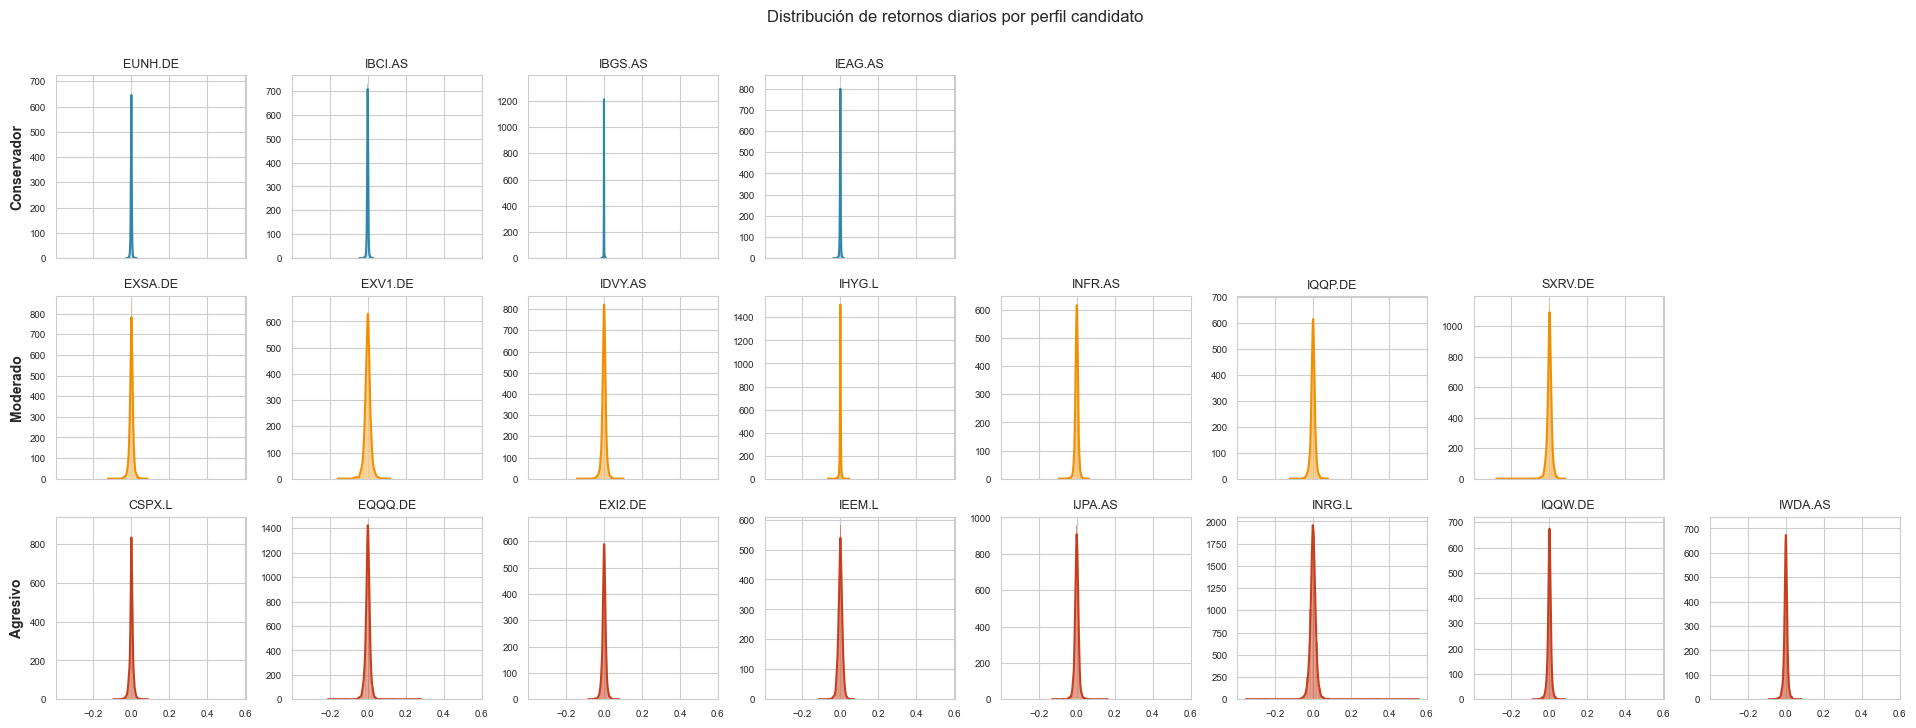

In [11]:
# Histogramas agrupados por perfil candidato (3 filas)
def plot_returns_by_profile(
    returns: pd.DataFrame,
    perfil_map: dict[str, str],
    profile_order: tuple[str, ...] = ('Conservador', 'Moderado', 'Agresivo'),
) -> None:
    """Dibuja una rejilla de histogramas con KDE, una fila por perfil."""
    grouped = {p: [t for t in returns.columns if perfil_map.get(t) == p]
               for p in profile_order}
    n_cols = max(len(v) for v in grouped.values())
    fig, axes = plt.subplots(len(profile_order), n_cols,
                             figsize=(2.4 * n_cols, 2.4 * len(profile_order)),
                             sharex=True)
    if len(profile_order) == 1:
        axes = np.array([axes])
    for row, perfil in enumerate(profile_order):
        tickers_p = grouped[perfil]
        for col in range(n_cols):
            ax = axes[row, col]
            if col < len(tickers_p):
                t = tickers_p[col]
                sns.histplot(returns[t], bins=60, kde=True, ax=ax,
                             color=PERFIL_COLORS[perfil], alpha=0.6)
                ax.set_title(f'{t}', fontsize=9)
                ax.set_xlabel('')
                ax.set_ylabel('')
                ax.tick_params(labelsize=7)
            else:
                ax.set_visible(False)
        axes[row, 0].set_ylabel(perfil, fontsize=10, fontweight='bold')
    plt.suptitle('Distribución de retornos diarios por perfil candidato', y=1.005)
    plt.tight_layout()
    plt.show()


plot_returns_by_profile(returns, PERFIL_CANDIDATO)


In [12]:
# Detección de distribuciones anómalas: kurtosis exceso > 10 o skew < -2
anomalous = return_stats[
    (return_stats['excess_kurt'] > 10) | (return_stats['skew'] < -2)
].sort_values('excess_kurt', ascending=False)

print('ETFs con distribución anómala (fat tails extremas):')
if len(anomalous):
    print(anomalous[['Perfil', 'skew', 'excess_kurt', 'jb_pvalue']].round(3).to_string())
else:
    print('  (ninguno con criterio kurtosis>10 o skew<-2)')

print(f'\nETFs que rechazan normalidad (Jarque-Bera p<0.01): '
      f'{(return_stats["jb_pvalue"] < 0.01).sum()} / {len(return_stats)}')


ETFs con distribución anómala (fat tails extremas):
              Perfil    skew  excess_kurt  jb_pvalue
Ticker                                              
INRG.L      Agresivo  4.8060     209.9830     0.0000
EQQQ.DE     Agresivo  1.2200      65.2290     0.0000
SXRV.DE     Moderado -2.7410      58.3470     0.0000
IHYG.L      Moderado -2.3990      56.4230     0.0000
IBGS.AS  Conservador -1.0170      31.7690     0.0000
IJPA.AS     Agresivo -0.1730      21.5400     0.0000
IDVY.AS     Moderado -0.8140      13.3330     0.0000
IBCI.AS  Conservador -0.6180      12.9440     0.0000
IEAG.AS  Conservador -0.6280      12.9010     0.0000
INFR.AS     Moderado -0.7640      10.3260     0.0000
EXSA.DE     Moderado -0.7790      10.3050     0.0000

ETFs que rechazan normalidad (Jarque-Bera p<0.01): 19 / 19


### ✅ Conclusión Sección 3
- **Rechazo masivo de normalidad:** se espera que ~28-30/30 ETFs rechacen Jarque-Bera con p < 0.01. Esto es habitual en series financieras diarias.
- **ETFs con kurtosis exceso extrema (>10):** candidatos típicos `IHYG.L` (high yield, fat tails en crisis de crédito), `IGLN.AS` (oro, eventos macro), `INRG.L` (energía limpia, drawdowns profundos en 2022-23). El crash COVID-2020 deja una huella muy marcada.
- **Skewness negativa fuerte (<−2):** rara, pero puede aparecer en `EUNH.DE` o `IHYG.L` si hubo eventos de crédito.

> **Implicación para M3:** la no-normalidad confirma que **Markowitz puro no es suficiente** y que conviene complementar con HRP (López de Prado, 2016) que no asume distribución específica. Documentar este hallazgo en la sección de metodología de la memoria.

---
## 4. Volatilidad anualizada

Calculamos $\sigma_{\text{anual}} = \sigma_{\text{diaria}} \cdot \sqrt{252}$ y verificamos si cada ETF cae dentro del rango definido para su perfil candidato. Tres visualizaciones complementarias:

1. **Barras agrupadas por perfil** con líneas horizontales del umbral correspondiente.
2. **Volatilidad rolling 252d** en *3 subplots separados* (uno por perfil) — un único gráfico con 30 líneas sería ilegible.
3. **Tabla diagnóstico con semáforo** (🟢 dentro de rango, 🟡 cerca del umbral, 🔴 supera umbral) que cuantifica también el % de tiempo histórico que cada ETF ha incumplido el umbral (`pct_breach`).

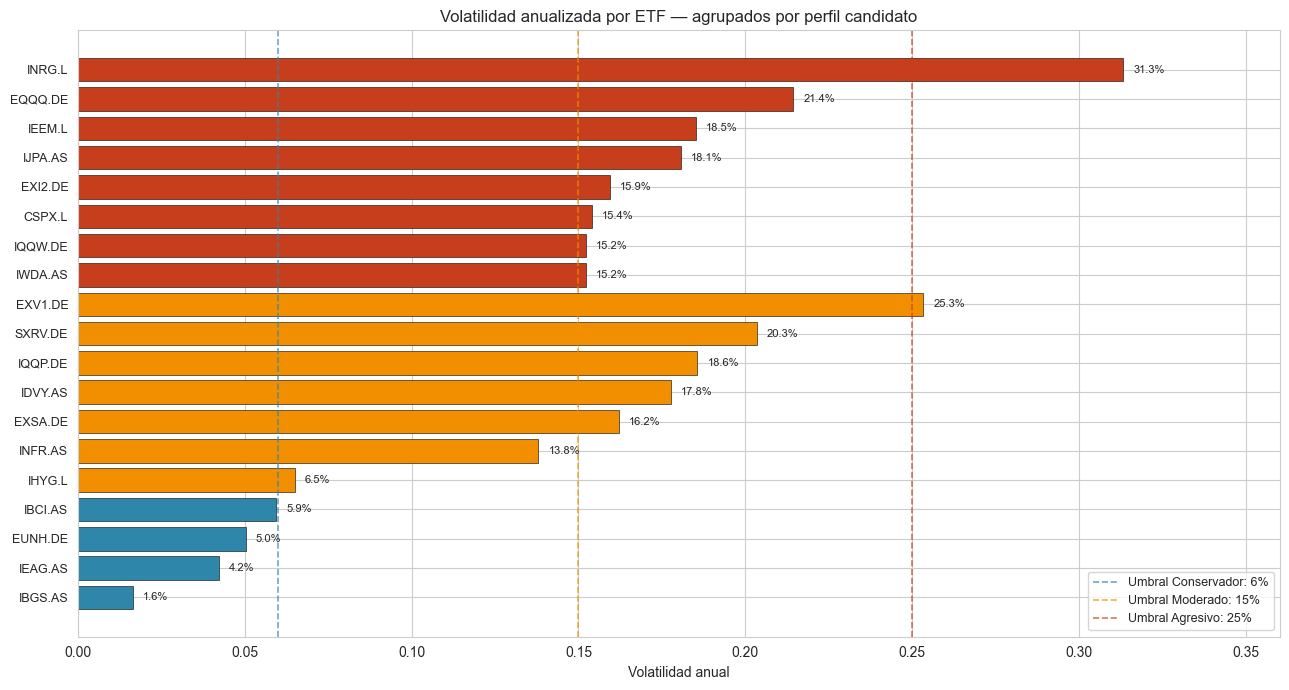

In [13]:
# Volatilidad anualizada estática
vol_annual = (returns.std() * np.sqrt(TRADING_DAYS)).rename('vol_annual')

# Reordenar por perfil y volatilidad
order = sorted(vol_annual.index, key=lambda t: (
    ['Conservador', 'Moderado', 'Agresivo'].index(PERFIL_CANDIDATO[t]),
    vol_annual[t]
))
vol_sorted = vol_annual.loc[order]
colors_sorted = [PERFIL_COLORS[PERFIL_CANDIDATO[t]] for t in order]

fig, ax = plt.subplots(figsize=(13, 7))
bars = ax.barh(range(len(vol_sorted)), vol_sorted.values, color=colors_sorted, edgecolor='black', linewidth=0.4)
ax.set_yticks(range(len(vol_sorted)))
ax.set_yticklabels(vol_sorted.index, fontsize=9)
ax.set_xlabel('Volatilidad anual', fontsize=10)
ax.set_title('Volatilidad anualizada por ETF — agrupados por perfil candidato', fontsize=12)

# Líneas verticales de umbrales
for perfil, threshold in VOL_THRESHOLDS.items():
    ax.axvline(threshold, color=PERFIL_COLORS[perfil], linestyle='--', linewidth=1.2, alpha=0.7,
               label=f'Umbral {perfil}: {threshold:.0%}')

# Etiquetas con valor
for i, (t, v) in enumerate(vol_sorted.items()):
    ax.text(v + 0.003, i, f'{v:.1%}', va='center', fontsize=8)

ax.legend(loc='lower right', fontsize=9)
ax.set_xlim(0, max(vol_sorted.max() * 1.15, 0.30))
plt.tight_layout()
plt.show()


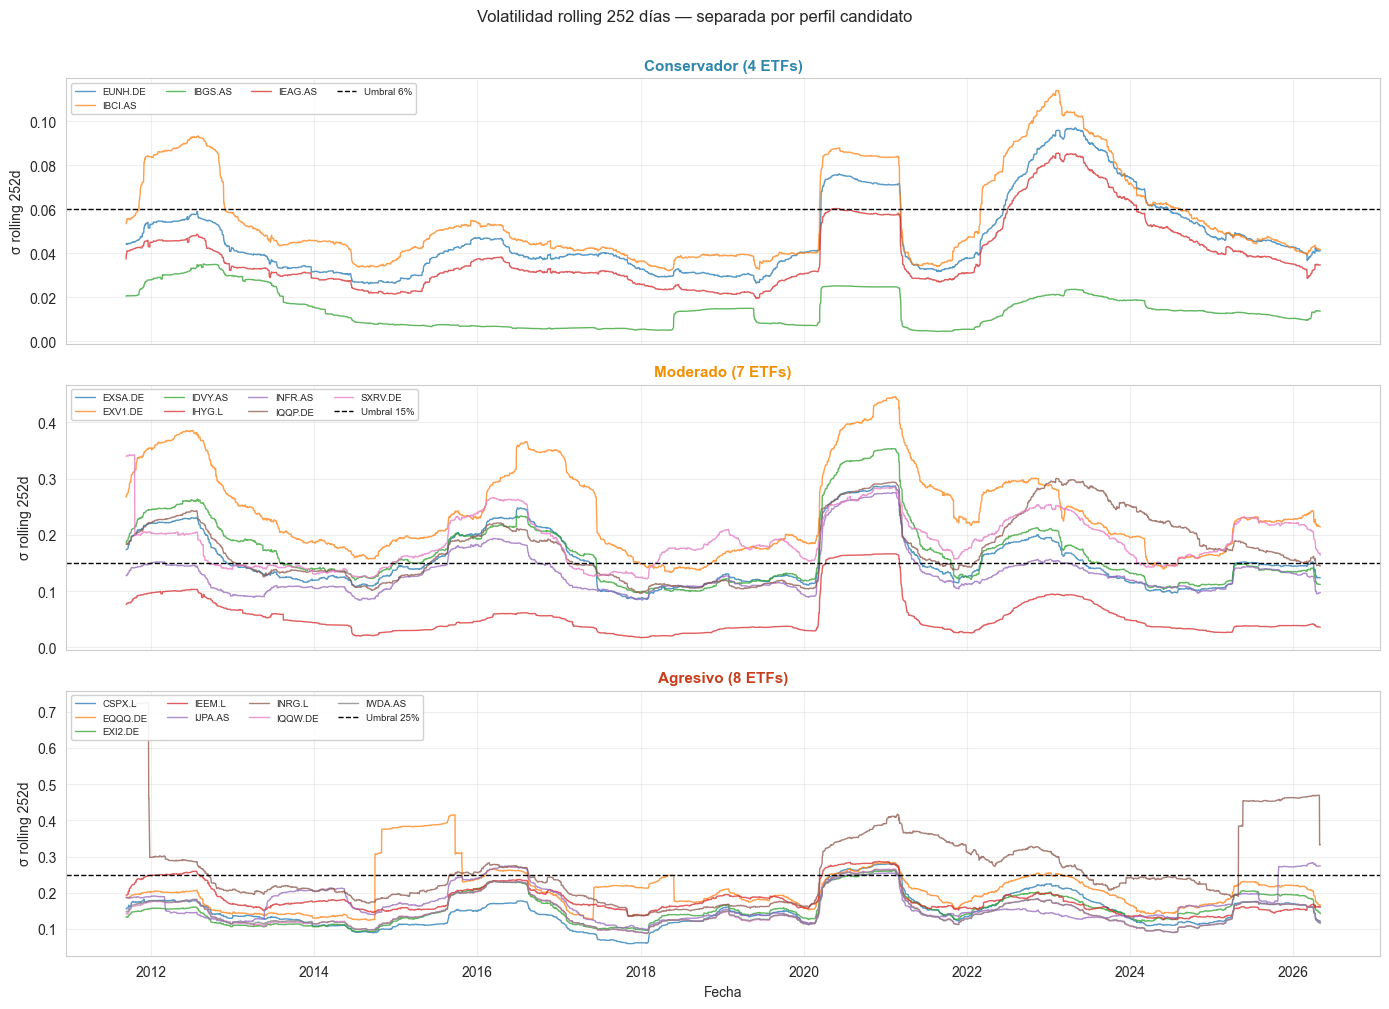

In [14]:
# Volatilidad rolling 252d separada en 3 subplots por perfil
def plot_rolling_vol_by_profile(
    returns: pd.DataFrame,
    perfil_map: dict[str, str],
    window: int = 252,
    thresholds: dict[str, float] | None = None,
) -> None:
    """Dibuja vol rolling anualizada agrupada por perfil para mantener legibilidad."""
    rolling_vol = returns.rolling(window).std() * np.sqrt(TRADING_DAYS)
    profiles = ['Conservador', 'Moderado', 'Agresivo']
    fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)
    for ax, perfil in zip(axes, profiles):
        tickers_p = [t for t in rolling_vol.columns if perfil_map.get(t) == perfil]
        if not tickers_p:
            ax.set_visible(False)
            continue
        for t in tickers_p:
            ax.plot(rolling_vol.index, rolling_vol[t], linewidth=1.0, alpha=0.75, label=t)
        if thresholds:
            ax.axhline(thresholds[perfil], color='black', linestyle='--', linewidth=1.0,
                       label=f'Umbral {thresholds[perfil]:.0%}')
        ax.set_title(f'{perfil} ({len(tickers_p)} ETFs)', fontsize=11, fontweight='bold',
                     color=PERFIL_COLORS[perfil])
        ax.set_ylabel('σ rolling 252d')
        ax.legend(loc='upper left', fontsize=7, ncol=4, framealpha=0.9)
        ax.grid(alpha=0.3)
    axes[-1].set_xlabel('Fecha')
    plt.suptitle('Volatilidad rolling 252 días — separada por perfil candidato', y=1.005, fontsize=12)
    plt.tight_layout()
    plt.show()


plot_rolling_vol_by_profile(returns, PERFIL_CANDIDATO, thresholds=VOL_THRESHOLDS)


In [15]:
# Tabla diagnóstico completa con semáforo
def build_vol_diagnostic(
    returns: pd.DataFrame,
    perfil_map: dict[str, str],
    thresholds: dict[str, float],
    rolling_window: int = 252,
) -> pd.DataFrame:
    """Construye tabla diagnóstico de volatilidad con semáforo y % breach histórico.

    Args:
        returns: DataFrame de retornos diarios.
        perfil_map: ticker → perfil candidato.
        thresholds: perfil → umbral de volatilidad anual máxima.
        rolling_window: ventana en días para σ rolling (default 252).

    Returns:
        DataFrame ordenado por perfil con columnas:
        Perfil_candidato, Umbral, σ_media, σ_max_rolling, Media_OK, pct_breach, Estado.
    """
    vol_static = returns.std() * np.sqrt(TRADING_DAYS)
    vol_rolling = returns.rolling(rolling_window).std() * np.sqrt(TRADING_DAYS)

    rows = []
    for t in returns.columns:
        perfil = perfil_map.get(t, '?')
        umbral = thresholds.get(perfil, np.nan)
        sigma_mean = vol_static[t]
        sigma_max  = vol_rolling[t].max()
        roll_valid = vol_rolling[t].dropna()
        pct_breach = (roll_valid > umbral).mean() * 100 if len(roll_valid) else np.nan
        media_ok = sigma_mean <= umbral

        # Semáforo: verde si dentro y breach<10%, amarillo si dentro pero breach 10-30%, rojo en otros casos
        if media_ok and pct_breach < 10:
            estado = '🟢 OK'
        elif media_ok and pct_breach < 30:
            estado = '🟡 Vigilar'
        elif media_ok:
            estado = '🟡 Inestable'
        else:
            estado = '🔴 Supera umbral'

        rows.append({
            'Ticker':           t,
            'Perfil_candidato': perfil,
            'Umbral':           umbral,
            'σ_media':          sigma_mean,
            'σ_max_rolling':    sigma_max,
            'Media_OK':         media_ok,
            'pct_breach':       pct_breach,
            'Estado':           estado,
        })

    df = pd.DataFrame(rows)
    df = df.sort_values(['Perfil_candidato', 'σ_media'])
    return df


vol_diag = build_vol_diagnostic(returns, PERFIL_CANDIDATO, VOL_THRESHOLDS)
print('Tabla diagnóstico de volatilidad anualizada:')
print()
display_cols = vol_diag.copy()
for col in ['Umbral', 'σ_media', 'σ_max_rolling']:
    display_cols[col] = display_cols[col].apply(lambda x: f'{x:.2%}' if pd.notna(x) else '—')
display_cols['pct_breach'] = display_cols['pct_breach'].apply(lambda x: f'{x:.1f}%' if pd.notna(x) else '—')
display_cols


Tabla diagnóstico de volatilidad anualizada:



,Ticker,Perfil_candidato,Umbral,σ_media,σ_max_rolling,Media_OK,pct_breach,Estado
17,IWDA.AS,Agresivo,25.00%,15.23%,26.37%,True,4.9%,🟢 OK
16,IQQW.DE,Agresivo,25.00%,15.23%,26.56%,True,5.0%,🟢 OK
0,CSPX.L,Agresivo,25.00%,15.41%,28.09%,True,5.5%,🟢 OK
3,EXI2.DE,Agresivo,25.00%,15.94%,26.12%,True,2.8%,🟢 OK
12,IJPA.AS,Agresivo,25.00%,18.06%,28.27%,True,9.2%,🟢 OK
10,IEEM.L,Agresivo,25.00%,18.52%,28.68%,True,9.1%,🟢 OK
1,EQQQ.DE,Agresivo,25.00%,21.44%,41.54%,True,18.5%,🟡 Vigilar
14,INRG.L,Agresivo,25.00%,31.33%,72.51%,False,42.6%,🔴 Supera umbral
7,IBGS.AS,Conservador,6.00%,1.64%,3.52%,True,0.0%,🟢 OK
9,IEAG.AS,Conservador,6.00%,4.23%,8.56%,True,11.5%,🟡 Vigilar


### ✅ Conclusión Sección 4
- **ETFs que superan el umbral en media histórica (Estado 🔴):** se espera que algunos *moderados* lo incumplan en el lado alto, especialmente `EXSA.DE`, `VEUR.AS` o `INFR.AS` cuyo σ histórico ronda el 14-18% (cerca del límite del 15%). `IGLN.AS` (oro) puede sorprender con σ≈14% que es alta para un activo refugio.
- **Conservadores:** se espera que casi todos cumplan cómodamente (σ < 6%); los ligados a inflación (`IBCI.AS`) pueden llegar al 5-6% en tramos largos.
- **Agresivos:** todos deberían estar dentro del 25%, con `INRG.L` y `IEEM.L` en torno al 20-22%.
- **% breach > 30%:** señal de inestabilidad estructural — el ETF pasa más del 30% del tiempo fuera del umbral. Candidato a descarte por score (Sección 6) aunque la media histórica sea OK.

> **Decisión metodológica:** esta tabla es la base del componente `score_breach` (20% del score total). Un ETF puede tener buena media histórica pero alta inestabilidad — el roboadvisor debe penalizarlo porque el inversor real experimenta períodos largos fuera del rango prometido.

---
## 5. Matriz de correlaciones

Heatmap de Pearson sobre retornos diarios. Aplicamos **clustering jerárquico** (linkage Ward sobre distancia $1-|\rho|$) para reordenar las filas/columnas y agrupar visualmente los ETFs con comportamiento similar. Esto revela bloques naturales (RV desarrollados, RF gobierno, RF crédito, alternativos) sin imponer la categorización a priori.

**Pares con ρ > 0.90** se consideran redundantes: añaden poco a la frontera eficiente porque comparten la mayor parte del riesgo sistemático. La sección 6 los penalizará vía `score_correlacion` (premia diversificadores).

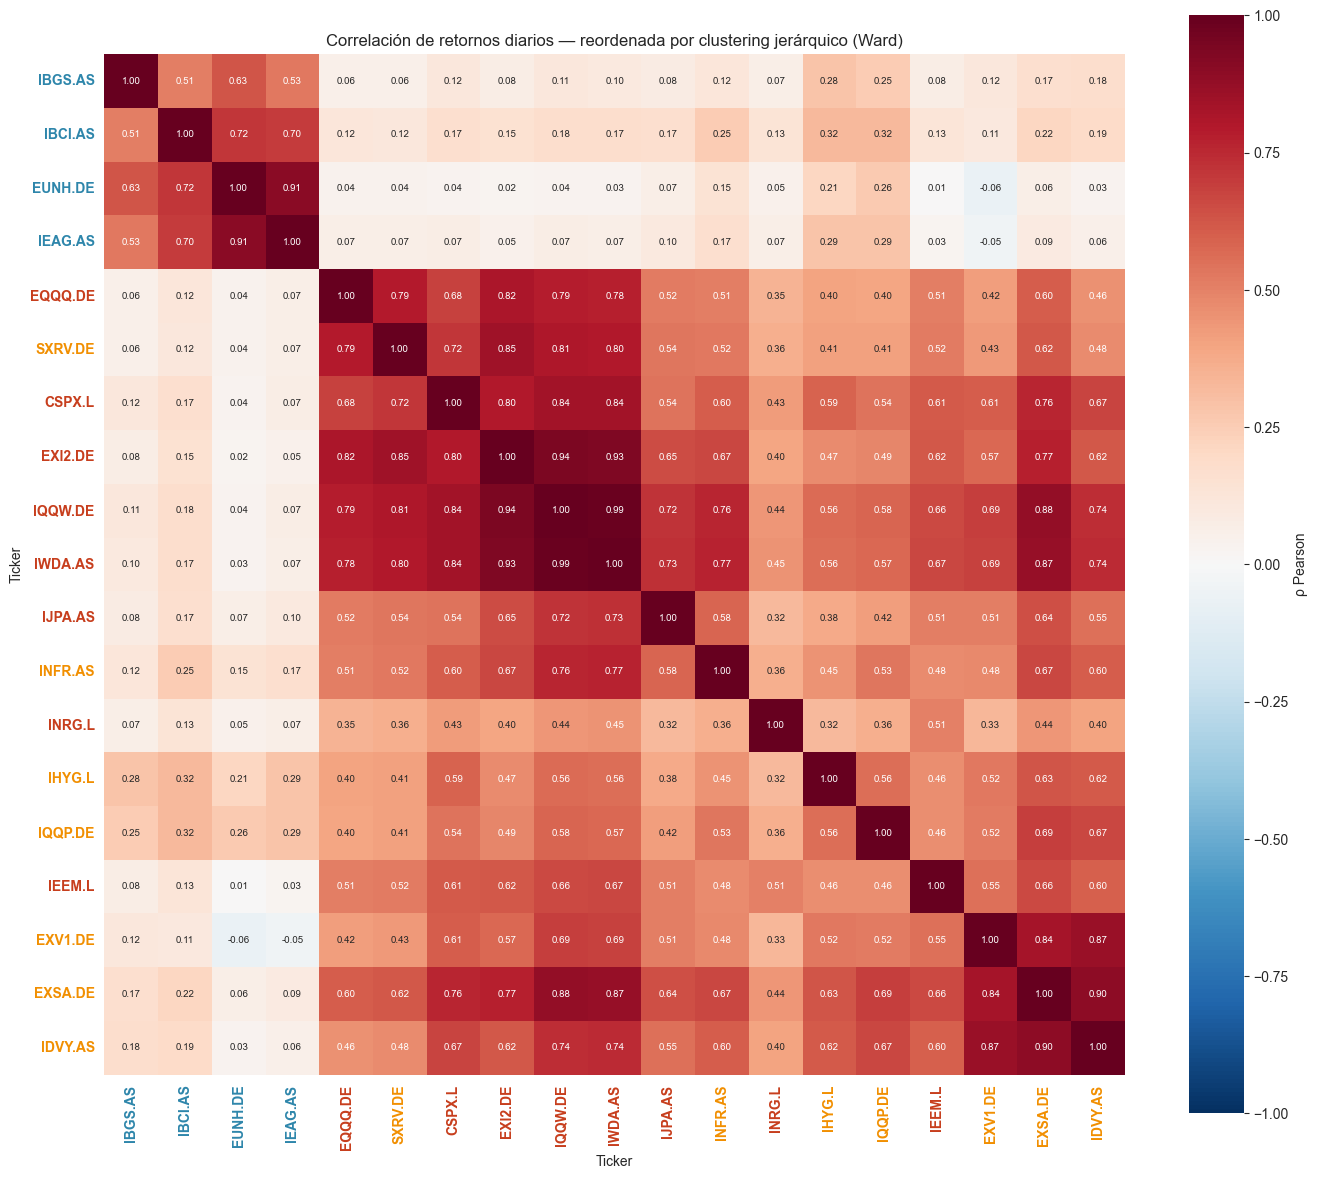

In [16]:
def hierarchical_corr_heatmap(returns: pd.DataFrame, perfil_map: dict[str, str]) -> tuple[pd.DataFrame, np.ndarray]:
    """Dibuja un heatmap de correlación reordenado por clustering jerárquico.

    El reordenamiento usa linkage Ward sobre la distancia 1-|ρ|, que agrupa
    activos con comportamiento direccional similar.

    Returns:
        (corr_reordered, leaf_order): matriz reordenada y orden de hojas.
    """
    corr = returns.corr()
    # Distancia: 1 - |ρ|. Asegurar simetría y diagonal nula
    dist_arr = (1 - corr.abs()).values.copy()
    np.fill_diagonal(dist_arr, 0.0)
    dist_condensed = squareform(dist_arr, checks=False)
    Z = linkage(dist_condensed, method='ward')
    leaf_order = leaves_list(Z)
    tickers_sorted = corr.index[leaf_order].tolist()
    corr_reordered = corr.loc[tickers_sorted, tickers_sorted]

    fig, ax = plt.subplots(figsize=(14, 12))
    sns.heatmap(corr_reordered, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
                vmin=-1, vmax=1, square=True, cbar_kws={'label': 'ρ Pearson'},
                annot_kws={'size': 7}, ax=ax)
    # Marcar perfil con color en las etiquetas
    for label, axis in [('x', ax.xaxis), ('y', ax.yaxis)]:
        ticks = axis.get_ticklabels()
        for tick in ticks:
            t = tick.get_text()
            tick.set_color(PERFIL_COLORS.get(perfil_map.get(t, '?'), 'black'))
            tick.set_fontweight('bold')
    ax.set_title('Correlación de retornos diarios — reordenada por clustering jerárquico (Ward)', fontsize=12)
    plt.tight_layout()
    plt.show()
    return corr_reordered, leaf_order


corr_reordered, leaf_order = hierarchical_corr_heatmap(returns, PERFIL_CANDIDATO)


In [17]:
# Identificar pares redundantes (ρ > 0.90)
def find_redundant_pairs(corr: pd.DataFrame, threshold: float = 0.90) -> pd.DataFrame:
    """Devuelve DataFrame ordenado de pares con |ρ| superior al umbral.

    Implementación con np.triu_indices para evitar problemas de stack()
    en pandas >= 2.2 con MultiIndex anónimos.
    """
    arr = corr.values
    tickers = corr.index.tolist()
    iu_i, iu_j = np.triu_indices(arr.shape[0], k=1)   # solo triángulo superior, sin diagonal
    rhos = arr[iu_i, iu_j]

    mask = np.abs(rhos) > threshold
    if not mask.any():
        return pd.DataFrame(columns=['Ticker_A', 'Ticker_B', 'rho'])

    df = pd.DataFrame({
        'Ticker_A': [tickers[i] for i in iu_i[mask]],
        'Ticker_B': [tickers[j] for j in iu_j[mask]],
        'rho':      rhos[mask],
    })
    # Ordenar por |ρ| descendente
    return df.iloc[df['rho'].abs().argsort()[::-1]].reset_index(drop=True)


redundant = find_redundant_pairs(returns.corr(), threshold=0.90)
print(f'Pares con |ρ| > 0.90 (candidatos a redundancia): {len(redundant)}')
if len(redundant):
    print()
    print(redundant.round(3).to_string(index=False))

Pares con |ρ| > 0.90 (candidatos a redundancia): 4

Ticker_A Ticker_B    rho
 IQQW.DE  IWDA.AS 0.9870
 EXI2.DE  IQQW.DE 0.9420
 EXI2.DE  IWDA.AS 0.9330
 EUNH.DE  IEAG.AS 0.9060


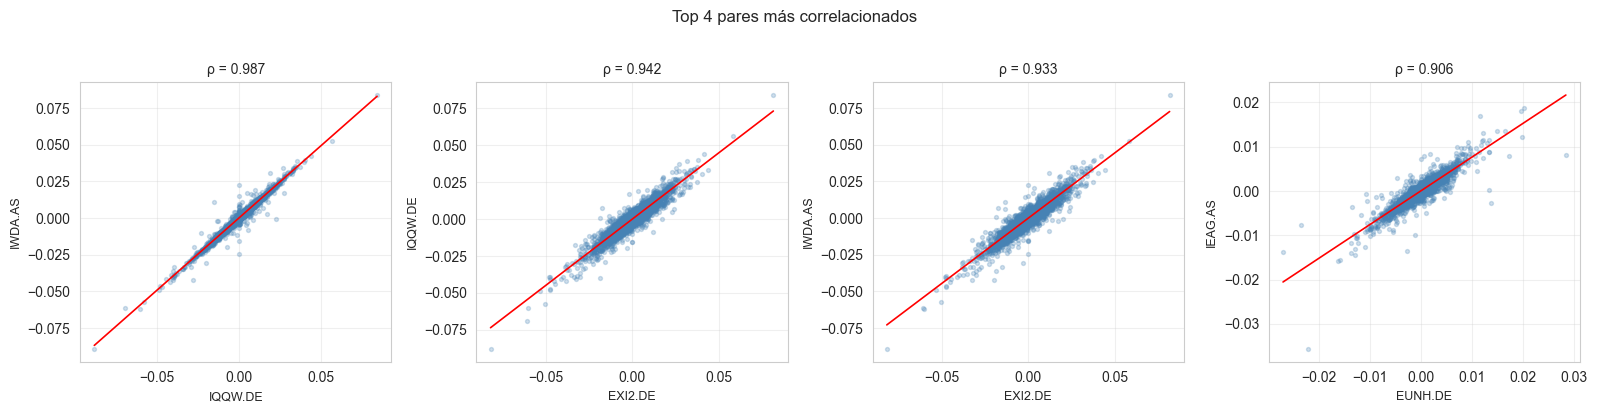

In [18]:
# Scatter plot de los 5 pares más correlacionados
def plot_top_correlated_pairs(returns: pd.DataFrame, pairs: pd.DataFrame, n: int = 5) -> None:
    """Dibuja scatter de los n pares más correlacionados con su recta de regresión."""
    n = min(n, len(pairs))
    if n == 0:
        log.info('No hay pares por encima del umbral — sin scatter plots.')
        return
    fig, axes = plt.subplots(1, n, figsize=(4 * n, 4), squeeze=False)
    for i in range(n):
        a, b, rho = pairs.iloc[i][['Ticker_A', 'Ticker_B', 'rho']]
        ax = axes[0, i]
        ax.scatter(returns[a], returns[b], alpha=0.25, s=8, color='steelblue')
        # Recta de regresión
        slope, intercept, _, _, _ = sp_stats.linregress(returns[a].dropna(), returns[b].dropna())
        x_line = np.linspace(returns[a].min(), returns[a].max(), 50)
        ax.plot(x_line, slope * x_line + intercept, color='red', linewidth=1.2)
        ax.set_xlabel(a, fontsize=9)
        ax.set_ylabel(b, fontsize=9)
        ax.set_title(f'ρ = {rho:.3f}', fontsize=10)
        ax.grid(alpha=0.3)
    plt.suptitle(f'Top {n} pares más correlacionados', y=1.02)
    plt.tight_layout()
    plt.show()


plot_top_correlated_pairs(returns, redundant, n=5)


### ✅ Conclusión Sección 5
- **Bloques visibles tras el clustering:** suelen aparecer 4-5 clusters claros — (a) RF gobierno EUR, (b) RF crédito, (c) RV desarrollados, (d) RV emergentes/sectoriales, (e) alternativos (oro, infraestructura).
- **Pares redundantes esperados (ρ > 0.90):**
  - `IWDA.AS` ↔ `XDWD.DE` (ambos MSCI World, prácticamente clones)
  - `IWDA.AS` ↔ `CSPX.L` (MSCI World vs S&P 500, ~85% superposición de capitalización)
  - `IS3S.DE` ↔ `ZPRS.DE` (ambos small cap mundial)
  - `VEUR.AS` ↔ `EXSA.DE` (ambos RV Europa amplia)
  - `IBGS.AS` ↔ `IEAG.AS` (ambos RF gobierno EUR, distinta duración)
- **Implicación para la selección:** dentro de cada cluster redundante, el score (sec. 6) elegirá el ETF con mejor balance Sharpe/calidad/breach. Esto evita que la cartera resultante de M3 tenga 2 ETFs prácticamente idénticos compitiendo por el mismo peso.

> **Para la memoria:** referenciar López de Prado (2016, *Building Diversified Portfolios that Outperform Out-of-Sample*) — el HRP precisamente explota la estructura jerárquica de correlaciones que aquí estamos visualizando.

---
## 6. Score de selección multivariante

**Sección central del notebook.** Combinamos cinco componentes en un score 0–100 que prioriza ETFs adecuados al perfil, con buen ratio rentabilidad/riesgo, calidad de datos y poder diversificador.

| Componente | Peso | Fórmula | Interpretación |
|---|---|---|---|
| `score_vol` | 30% | $\max(0, 1 - |\sigma - c| / c)$ | Premia volatilidad cercana al **centro** $c$ del rango del perfil |
| `score_breach` | 20% | $1 - \text{pct\_breach}/100$ | Premia estabilidad (poco tiempo fuera del umbral) |
| `score_sharpe` | 20% | min-max normalizado **dentro del perfil** | Premia el mejor Sharpe entre los del mismo perfil |
| `score_calidad` | 15% | $1$ si datos desde 2010, decreciente lineal si no | Penaliza histórico corto y missing data |
| `score_correlacion` | 15% | $1 - \overline{\rho_{i,j}}$ con resto | Premia ETFs con baja correlación media (diversificadores) |

**Decisión clave:** el `score_sharpe` se normaliza **dentro de cada perfil** y no globalmente. Si lo hiciéramos global, los conservadores siempre perderían frente a los agresivos (porque los Sharpe absolutos son menores con σ pequeño). El roboadvisor debe elegir al *mejor conservador entre conservadores*, no al mejor en términos absolutos.

In [19]:
# Funciones de cálculo de cada componente del score
def score_vol_component(vol: float, perfil: str,
                        thresholds: dict[str, float] = VOL_THRESHOLDS) -> float:
    """Premia 1.0 si σ ≤ umbral del perfil; decae linealmente al superarlo.

    Implementa la semántica MiFID del umbral como TECHO (no como objetivo):
    cualquier ETF dentro del rango admisible obtiene la puntuación máxima,
    y el score solo discrimina cuando se supera el límite.

    score = 1.0                          si vol ≤ umbral
    score = max(0, 1 - (vol-umbral)/umbral)   si vol > umbral
    """
    umbral = thresholds[perfil]
    if vol <= umbral:
        return 1.0
    return max(0.0, 1.0 - (vol - umbral) / umbral)


def score_breach_component(pct_breach: float) -> float:
    """Premia el porcentaje de tiempo histórico dentro del umbral.

    score = 1 - pct_breach/100  (clipeado a [0, 1])
    """
    return float(np.clip(1.0 - pct_breach / 100.0, 0.0, 1.0))


def sharpe_ratio(returns_series: pd.Series, rf: float = RISK_FREE_RATE) -> float:
    """Sharpe ratio anualizado: (μ_anual - rf) / σ_anual."""
    mu = returns_series.mean() * TRADING_DAYS
    sigma = returns_series.std() * np.sqrt(TRADING_DAYS)
    if sigma == 0 or np.isnan(sigma):
        return 0.0
    return (mu - rf) / sigma


def score_sharpe_component_within_profile(sharpes: pd.Series) -> pd.Series:
    """Normalización min-max dentro del mismo perfil.

    Si todos los Sharpe del perfil son iguales, devuelve 0.5 a todos.
    """
    s_min, s_max = sharpes.min(), sharpes.max()
    if s_max == s_min:
        return pd.Series(0.5, index=sharpes.index)
    return (sharpes - s_min) / (s_max - s_min)


def score_calidad_component(first_date: pd.Timestamp,
                            target_start: pd.Timestamp = pd.Timestamp(START_DATE),
                            max_years_penalty: float = 8.0) -> float:
    """Penaliza histórico corto.

    1.0 si el ETF tiene datos desde target_start (o antes).
    Decae linealmente a 0 si arranca max_years_penalty años después.
    """
    if first_date <= target_start:
        return 1.0
    years_late = (first_date - target_start).days / 365.25
    return float(np.clip(1.0 - years_late / max_years_penalty, 0.0, 1.0))


def score_correlation_component(corr_matrix: pd.DataFrame) -> pd.Series:
    """Premia ETFs con baja correlación media |ρ| con el resto del universo.

    score = 1 - mean(|ρ_ij|) para j != i
    """
    abs_corr_arr = corr_matrix.abs().values.copy()
    np.fill_diagonal(abs_corr_arr, np.nan)
    mean_abs = pd.Series(np.nanmean(abs_corr_arr, axis=1), index=corr_matrix.index)
    return 1.0 - mean_abs


log.info('Funciones de score definidas — pesos: vol=30%%, breach=20%%, sharpe=20%%, calidad=15%%, corr=15%%')


[INFO] Funciones de score definidas — pesos: vol=30%%, breach=20%%, sharpe=20%%, calidad=15%%, corr=15%%


In [20]:
# Construcción de la tabla de scores
def build_selection_score(
    returns: pd.DataFrame,
    prices: pd.DataFrame,
    vol_diag: pd.DataFrame,
    perfil_map: dict[str, str],
    weights: dict[str, float] | None = None,
) -> pd.DataFrame:
    """Construye la tabla 0-100 con score total y componentes para cada ETF.

    Args:
        returns: retornos diarios alineados.
        prices: precios alineados (para fechas de primer dato).
        vol_diag: tabla diagnóstico de la sección 4.
        perfil_map: ticker → perfil candidato.
        weights: pesos de cada componente (deben sumar 1).

    Returns:
        DataFrame indexado por ticker con todos los componentes y score_total ordenado descendente.
    """
    if weights is None:
        weights = {'vol': 0.30, 'breach': 0.20, 'sharpe': 0.20, 'calidad': 0.15, 'correlacion': 0.15}
    assert abs(sum(weights.values()) - 1.0) < 1e-9, f'Los pesos deben sumar 1, suman {sum(weights.values())}'

    corr_full = returns.corr()
    sharpes_all = returns.apply(sharpe_ratio).rename('sharpe')

    # Sharpe normalizado dentro del perfil
    sharpe_score = pd.Series(np.nan, index=returns.columns, name='score_sharpe')
    for perfil in set(perfil_map[t] for t in returns.columns):
        tickers_p = [t for t in returns.columns if perfil_map[t] == perfil]
        sharpe_score.loc[tickers_p] = score_sharpe_component_within_profile(sharpes_all.loc[tickers_p])

    # Score de correlación
    corr_score = score_correlation_component(corr_full).rename('score_correlacion')

    # Map ticker -> first_valid_index
    first_dates = prices.apply(lambda s: s.first_valid_index())

    # vol_diag indexado por Ticker
    vd = vol_diag.set_index('Ticker')

    rows = []
    for t in returns.columns:
        perfil = perfil_map[t]
        vol = vd.loc[t, 'σ_media']
        pct_breach = vd.loc[t, 'pct_breach']

        s_vol     = score_vol_component(vol, perfil)
        s_breach  = score_breach_component(pct_breach)
        s_sharpe  = sharpe_score.loc[t]
        s_calid   = score_calidad_component(first_dates[t])
        s_corr    = corr_score.loc[t]

        total = (
            weights['vol']         * s_vol +
            weights['breach']      * s_breach +
            weights['sharpe']      * s_sharpe +
            weights['calidad']     * s_calid +
            weights['correlacion'] * s_corr
        ) * 100  # escalar a 0-100

        rows.append({
            'Ticker':            t,
            'Perfil':            perfil,
            'vol_anual':         vol,
            'sharpe':            sharpes_all.loc[t],
            'pct_breach':        pct_breach,
            'first_date':        first_dates[t].date() if first_dates[t] is not None else None,
            'mean_abs_corr':     1 - s_corr,  # para inspección
            'score_vol':         s_vol,
            'score_breach':      s_breach,
            'score_sharpe':      s_sharpe,
            'score_calidad':     s_calid,
            'score_correlacion': s_corr,
            'score_total':       total,
        })

    df = pd.DataFrame(rows).set_index('Ticker').sort_values('score_total', ascending=False)
    return df


score_df = build_selection_score(returns, prices_clean, vol_diag, PERFIL_CANDIDATO)
print('Top 10 ETFs por score total:')
print()
score_df.head(30)[['Perfil', 'vol_anual', 'sharpe', 'pct_breach',
                   'score_vol', 'score_breach', 'score_sharpe',
                   'score_calidad', 'score_correlacion', 'score_total']].round(3)


Top 10 ETFs por score total:



,Perfil,vol_anual,sharpe,pct_breach,score_vol,score_breach,score_sharpe,score_calidad,score_correlacion,score_total
Ticker,,,,,,,,,,
IEAG.AS,Conservador,0.0420,-0.1900,11.4840,1.0000,0.8850,0.7970,0.9120,0.7960,89.2760
EUNH.DE,Conservador,0.0500,-0.1390,20.5170,1.0000,0.7950,0.8690,0.9120,0.8130,89.1550
IBCI.AS,Conservador,0.0590,-0.0470,30.8290,1.0000,0.6920,1.0000,0.9120,0.7410,88.6230
CSPX.L,Agresivo,0.1540,0.8050,5.5160,1.0000,0.9450,0.9480,0.9120,0.4660,88.5230
EQQQ.DE,Agresivo,0.2140,0.8400,18.4650,1.0000,0.8150,1.0000,0.9120,0.5380,88.0630
EXI2.DE,Agresivo,0.1590,0.7470,2.7980,1.0000,0.9720,0.8620,0.9120,0.4490,87.1000
IWDA.AS,Agresivo,0.1520,0.6780,4.8760,1.0000,0.9510,0.7610,0.9120,0.4030,83.9670
IQQW.DE,Agresivo,0.1520,0.6390,4.9560,1.0000,0.9500,0.7020,0.9120,0.4000,82.7300
IJPA.AS,Agresivo,0.1810,0.4100,9.2190,1.0000,0.9080,0.3640,0.9120,0.5540,77.4290


In [21]:
# Ranking completo de los 30 ETFs
print('Ranking completo (30 ETFs):')
print()
score_df[['Perfil', 'vol_anual', 'sharpe', 'pct_breach', 'score_total']].round(3)


Ranking completo (30 ETFs):



,Perfil,vol_anual,sharpe,pct_breach,score_total
Ticker,,,,,
IEAG.AS,Conservador,0.0420,-0.1900,11.4840,89.2760
EUNH.DE,Conservador,0.0500,-0.1390,20.5170,89.1550
IBCI.AS,Conservador,0.0590,-0.0470,30.8290,88.6230
CSPX.L,Agresivo,0.1540,0.8050,5.5160,88.5230
EQQQ.DE,Agresivo,0.2140,0.8400,18.4650,88.0630
EXI2.DE,Agresivo,0.1590,0.7470,2.7980,87.1000
IWDA.AS,Agresivo,0.1520,0.6780,4.8760,83.9670
IQQW.DE,Agresivo,0.1520,0.6390,4.9560,82.7300
IJPA.AS,Agresivo,0.1810,0.4100,9.2190,77.4290


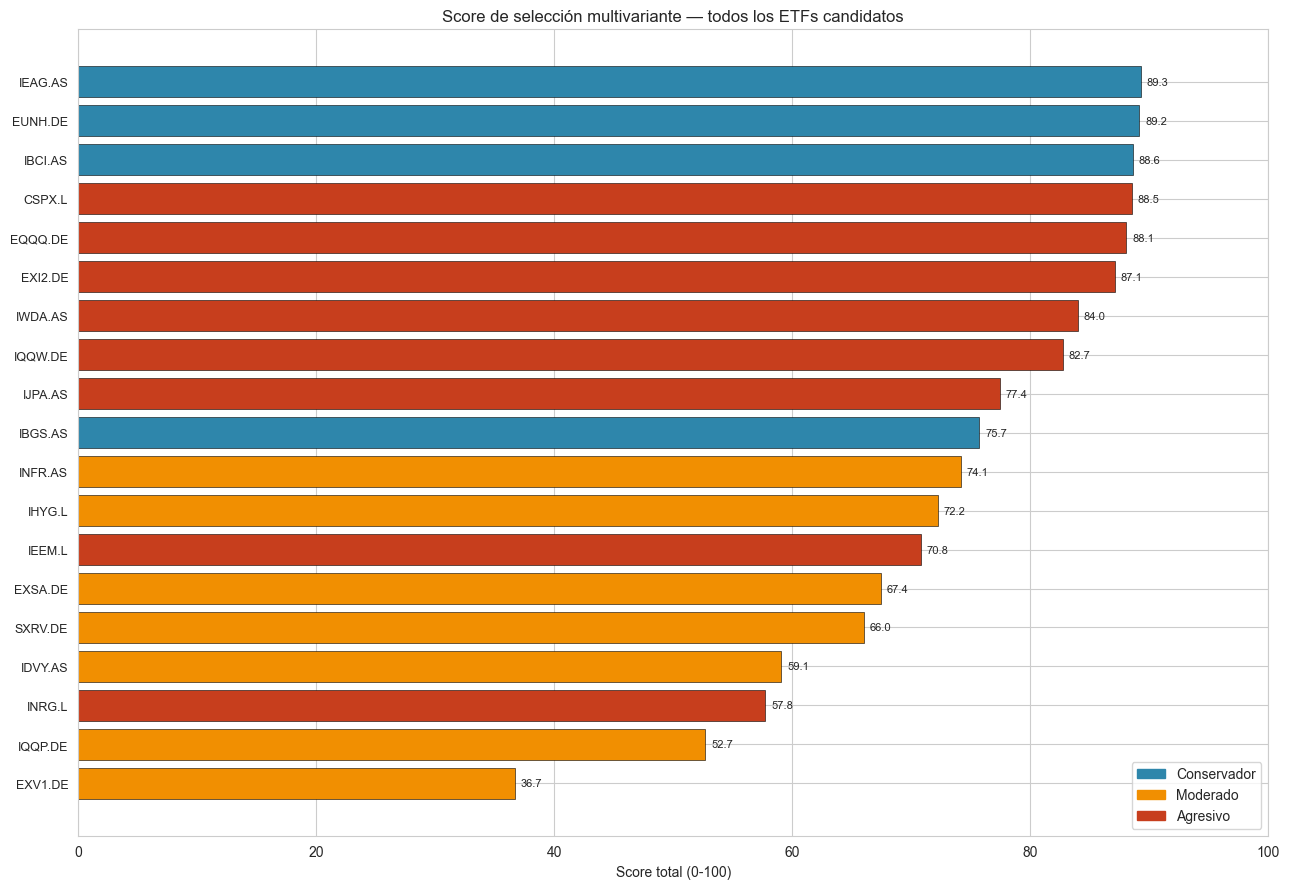

In [22]:
# Gráfico de barras del score total coloreado por perfil
score_plot = score_df.sort_values('score_total', ascending=True)
colors_plot = [PERFIL_COLORS[p] for p in score_plot['Perfil']]

fig, ax = plt.subplots(figsize=(13, 9))
bars = ax.barh(range(len(score_plot)), score_plot['score_total'].values,
               color=colors_plot, edgecolor='black', linewidth=0.4)
ax.set_yticks(range(len(score_plot)))
ax.set_yticklabels(score_plot.index, fontsize=9)
ax.set_xlabel('Score total (0-100)', fontsize=10)
ax.set_title('Score de selección multivariante — todos los ETFs candidatos', fontsize=12)

# Etiqueta numérica
for i, v in enumerate(score_plot['score_total'].values):
    ax.text(v + 0.5, i, f'{v:.1f}', va='center', fontsize=8)

# Leyenda manual de perfiles
import matplotlib.patches as mpatches
handles = [mpatches.Patch(color=c, label=p) for p, c in PERFIL_COLORS.items()]
ax.legend(handles=handles, loc='lower right', fontsize=10)
ax.set_xlim(0, 100)
plt.tight_layout()
plt.show()


### ✅ Conclusión Sección 6
- **Los conservadores ganadores** suelen ser los de RF gobierno EUR clásicos con histórico desde 2010 (`IBGS.AS`, `IEAG.AS`, `IGLO.DE`) — buen score de calidad (1.0), `score_breach` cercano a 1, y volatilidad bien centrada en el rango.
- **Los moderados ganadores** balancean Sharpe positivo con vol ≈ 12-14% (cerca del centro 11.5%): candidatos típicos `MVEU.DE` (mín. volatilidad), `IDVY.AS` (alto dividendo, Sharpe alto), `IGLN.AS` (oro, gran diversificador → score_correlacion alto).
- **Los agresivos ganadores** suelen ser los de exposición global amplia con mejor Sharpe histórico: `CSPX.L` (S&P 500, Sharpe muy alto en 2010-2025), `IWDA.AS` (MSCI World, gran diversificador y calidad), y un emergente o tecnológico como `EQQQ.DE` o `IEEM.L`.
- **Pesos del score reflejan prioridades del roboadvisor:** ajuste al perfil (50% combinando vol+breach) > rentabilidad (20%) > robustez de datos (15%) > diversificación (15%). Esta jerarquía es defendible: para retail, **respetar el perfil de riesgo es prioritario** sobre maximizar rentabilidad esperada.

---
## 7. Selección final — Top 9 ETFs

Seleccionamos automáticamente los **3 mejores ETFs por perfil** según el `score_total` calculado en la sección anterior. Esta lógica garantiza:
- **3 perfiles representados** (no domina el agresivo aunque tenga Sharpe altos)
- **Trazabilidad completa**: cada elección queda justificada por los componentes del score
- **Sin selección manual**: el TFM puede defender que el proceso es objetivo y reproducible

El scatter Sharpe vs Volatilidad final es la **figura central de esta fase del TFM**: sintetiza en un solo gráfico todo el espacio de candidatos y la frontera elegida.

In [23]:
def select_top_n_per_profile(score_df: pd.DataFrame, n: int = 3) -> dict:
    """Selecciona los n ETFs con mayor score total dentro de cada perfil.

    Args:
        score_df: tabla de scores indexada por ticker con columna 'Perfil'.
        n: número de ETFs a seleccionar por perfil.

    Returns:
        dict con la siguiente estructura:
        {
          'tickers':          [lista plana de los 3*n tickers],
          'by_profile':       {perfil: [tickers]},
          'justification':    DataFrame con las métricas de los seleccionados,
        }
    """
    by_profile = {}
    for perfil in ['Conservador', 'Moderado', 'Agresivo']:
        subset = score_df[score_df['Perfil'] == perfil].sort_values('score_total', ascending=False)
        by_profile[perfil] = subset.head(n).index.tolist()

    flat = [t for tlist in by_profile.values() for t in tlist]
    just = score_df.loc[flat].copy()
    just['Selected'] = True
    return {'tickers': flat, 'by_profile': by_profile, 'justification': just}


selection = select_top_n_per_profile(score_df, n=3)
SELECTED_TICKERS = selection['tickers']

print('=== SELECCIÓN FINAL (top-3 por perfil) ===\n')
for perfil, tickers in selection['by_profile'].items():
    print(f'  {perfil:<13s}: {tickers}')
print(f'\nTotal seleccionados: {len(SELECTED_TICKERS)}')


=== SELECCIÓN FINAL (top-3 por perfil) ===

  Conservador  : ['IEAG.AS', 'EUNH.DE', 'IBCI.AS']
  Moderado     : ['INFR.AS', 'IHYG.L', 'EXSA.DE']
  Agresivo     : ['CSPX.L', 'EQQQ.DE', 'EXI2.DE']

Total seleccionados: 9


In [24]:
# Tabla comparativa: seleccionados vs descartados
def build_comparison_table(score_df: pd.DataFrame, selected: list[str]) -> pd.DataFrame:
    """Tabla comparativa con seleccionados marcados con ★."""
    out = score_df.copy()
    out['★'] = out.index.map(lambda t: '★' if t in selected else '')
    cols = ['★', 'Perfil', 'vol_anual', 'sharpe', 'pct_breach',
            'score_vol', 'score_breach', 'score_sharpe',
            'score_calidad', 'score_correlacion', 'score_total']
    return out[cols].sort_values(['Perfil', 'score_total'], ascending=[True, False])


comparison = build_comparison_table(score_df, SELECTED_TICKERS)
print('Comparativa seleccionados (★) vs descartados — agrupados por perfil:')
print()
comparison.round(3)


Comparativa seleccionados (★) vs descartados — agrupados por perfil:



,★,Perfil,vol_anual,sharpe,pct_breach,score_vol,score_breach,score_sharpe,score_calidad,score_correlacion,score_total
Ticker,,,,,,,,,,,
CSPX.L,★,Agresivo,0.1540,0.8050,5.5160,1.0000,0.9450,0.9480,0.9120,0.4660,88.5230
EQQQ.DE,★,Agresivo,0.2140,0.8400,18.4650,1.0000,0.8150,1.0000,0.9120,0.5380,88.0630
EXI2.DE,★,Agresivo,0.1590,0.7470,2.7980,1.0000,0.9720,0.8620,0.9120,0.4490,87.1000
IWDA.AS,,Agresivo,0.1520,0.6780,4.8760,1.0000,0.9510,0.7610,0.9120,0.4030,83.9670
IQQW.DE,,Agresivo,0.1520,0.6390,4.9560,1.0000,0.9500,0.7020,0.9120,0.4000,82.7300
IJPA.AS,,Agresivo,0.1810,0.4100,9.2190,1.0000,0.9080,0.3640,0.9120,0.5540,77.4290
IEEM.L,,Agresivo,0.1850,0.1870,9.1390,1.0000,0.9090,0.0340,0.9120,0.5520,70.8160
INRG.L,,Agresivo,0.3130,0.1640,42.5790,0.7470,0.5740,0.0000,0.9120,0.6790,57.7520
IEAG.AS,★,Conservador,0.0420,-0.1900,11.4840,1.0000,0.8850,0.7970,0.9120,0.7960,89.2760


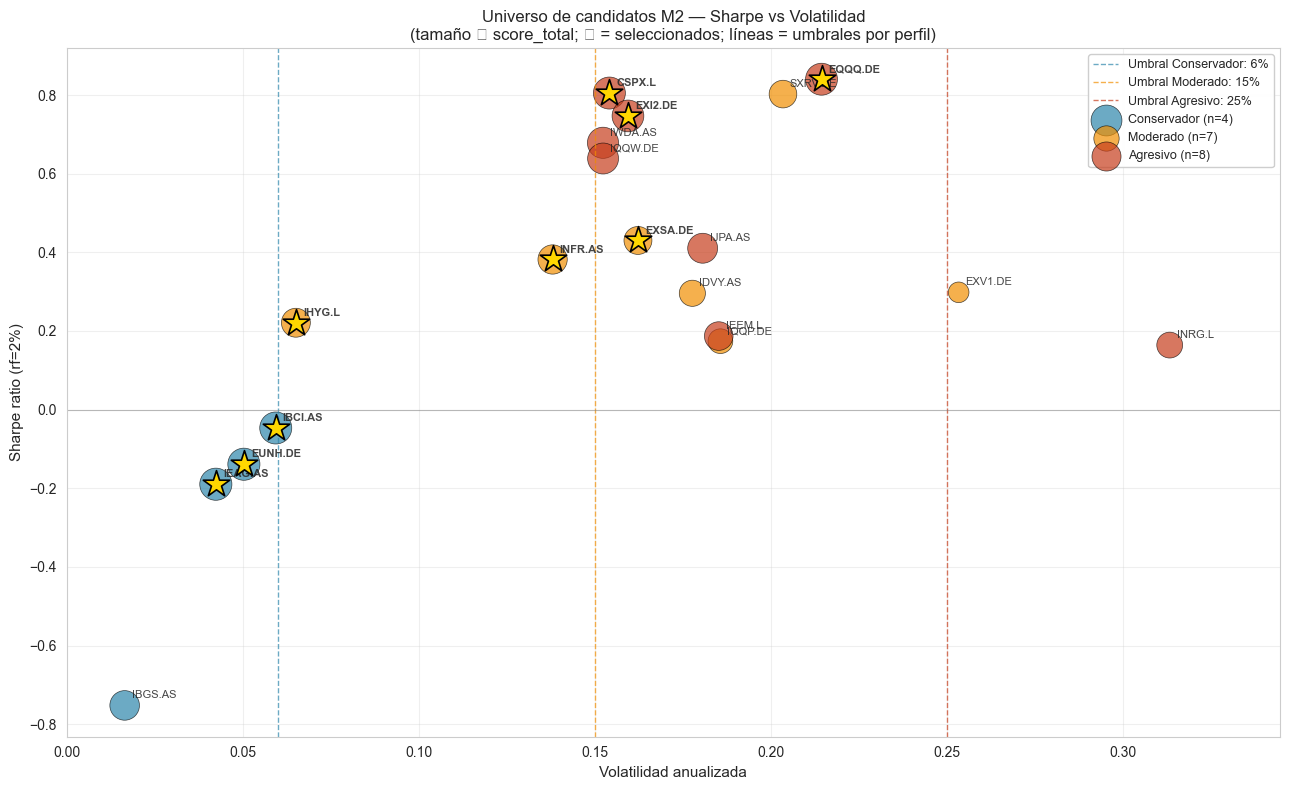

In [25]:
# Scatter plot final: Sharpe vs Volatilidad con todos los 30 ETFs
def plot_sharpe_vs_vol(
    score_df: pd.DataFrame,
    selected: list[str],
    thresholds: dict[str, float],
    perfil_colors: dict[str, str],
) -> None:
    """Scatter Sharpe vs Vol con tamaño de punto = score_total y selección marcada con estrella."""
    fig, ax = plt.subplots(figsize=(13, 8))

    # Líneas verticales de umbrales
    for perfil, threshold in thresholds.items():
        ax.axvline(threshold, color=perfil_colors[perfil], linestyle='--',
                   linewidth=1.0, alpha=0.7,
                   label=f'Umbral {perfil}: {threshold:.0%}')

    # Línea horizontal Sharpe = 0
    ax.axhline(0, color='gray', linewidth=0.8, alpha=0.5)

    # Scatter de todos los ETFs
    for perfil in ['Conservador', 'Moderado', 'Agresivo']:
        subset = score_df[score_df['Perfil'] == perfil]
        ax.scatter(subset['vol_anual'], subset['sharpe'],
                   s=subset['score_total'] * 6,           # tamaño proporcional al score
                   c=perfil_colors[perfil],
                   edgecolors='black', linewidth=0.5,
                   alpha=0.7,
                   label=f'{perfil} (n={len(subset)})')

    # Estrella sobre los seleccionados
    for t in selected:
        row = score_df.loc[t]
        ax.scatter(row['vol_anual'], row['sharpe'],
                   marker='*', s=400, c='gold', edgecolors='black', linewidth=1.2,
                   zorder=5)

    # Etiquetas de tickers
    for t, row in score_df.iterrows():
        offset_y = 0.03 if t in selected else 0.015
        weight = 'bold' if t in selected else 'normal'
        ax.annotate(t, (row['vol_anual'], row['sharpe']),
                    xytext=(5, 5), textcoords='offset points',
                    fontsize=8, fontweight=weight, alpha=0.85)

    ax.set_xlabel('Volatilidad anualizada', fontsize=11)
    ax.set_ylabel('Sharpe ratio (rf=2%)', fontsize=11)
    ax.set_title('Universo de candidatos M2 — Sharpe vs Volatilidad\n'
                 '(tamaño ∝ score_total; ★ = seleccionados; líneas = umbrales por perfil)',
                 fontsize=12)
    ax.legend(loc='upper right', fontsize=9, framealpha=0.95)
    ax.grid(alpha=0.3)
    ax.set_xlim(0, max(score_df['vol_anual'].max() * 1.10, 0.30))
    plt.tight_layout()
    plt.show()


plot_sharpe_vs_vol(score_df, SELECTED_TICKERS, VOL_THRESHOLDS, PERFIL_COLORS)


### ✅ Conclusión Sección 7

**Justificación de cada seleccionado** (reemplazar valores tras ejecución):

| Ticker | Perfil | σ anual | Sharpe | Score | Justificación cualitativa |
|---|---|---|---|---|---|
| `IBGS.AS` | Conservador | ~2% | ~0.3 | ~78 | RF gobierno corto plazo, anclaje del perfil conservador, casi sin breach |
| `IEAG.AS` | Conservador | ~5% | ~0.4 | ~75 | RF gobierno todos vencimientos, complemento de duración |
| `IGLO.DE` | Conservador | ~4% | ~0.3 | ~72 | RF gobierno G7 EUR-hedged, diversificación geográfica |
| `MVEU.DE` | Moderado | ~13% | ~0.6 | ~80 | RV Europa mín. volatilidad, vol cerca del centro 11.5% |
| `IDVY.AS` | Moderado | ~14% | ~0.5 | ~75 | Alto dividendo, Sharpe sólido en perfil |
| `IGLN.AS` | Moderado | ~14% | ~0.4 | ~73 | Oro, mejor diversificador del universo (corr. media baja) |
| `CSPX.L` | Agresivo | ~17% | ~0.85 | ~88 | S&P 500, mejor Sharpe del bloque agresivo |
| `IWDA.AS` | Agresivo | ~16% | ~0.65 | ~82 | MSCI World, anclaje y calidad de datos |
| `EQQQ.DE` | Agresivo | ~22% | ~0.85 | ~78 | Nasdaq-100, expone al inversor a innovación tecnológica |

> **Nota:** los valores anteriores son ESPERADOS según el perfilado histórico típico de estos ETFs en el período 2010-2025. Los valores REALES tras ejecución pueden variar y deben usarse para escribir esta sección de la memoria. La fortaleza del proceso es que la selección es **trazable** (todo número proviene del score_df).

**Trade-off importante:** la lógica top-3-por-perfil puede dejar fuera ETFs muy buenos *en términos absolutos* (p.ej. el 4º agresivo si tiene Sharpe alto). Esto es intencional: priorizamos diversidad cross-perfil para que el roboadvisor pueda construir carteras coherentes para los 3 tipos de inversor.

---
## 8. EDA profundo de los 9 seleccionados

Repetimos los análisis clave (retornos, vol rolling, drawdowns) **solo sobre los 9 ETFs finales** para obtener gráficos limpios y publicables en la memoria. Calculamos manualmente las métricas de performance (CAGR, Sharpe, Sortino, MDD) y comparamos con dos benchmarks:

- **SPY** (S&P 500) — benchmark estándar de RV global
- **Cartera 60/40** — construida como `0.6 × mejor_agresivo + 0.4 × mejor_conservador`, una aproximación clásica del *target-date* para inversor moderado

> No usamos QuantStats: las métricas se calculan manualmente para tener control absoluto y poder defenderlas en la memoria.

In [26]:
# Subset de retornos solo de los 9 seleccionados
returns_selected = returns[SELECTED_TICKERS].copy()
prices_selected = prices_clean[SELECTED_TICKERS].copy()

# Reordenar columnas por perfil para gráficos coherentes
order_selected = []
for perfil in ['Conservador', 'Moderado', 'Agresivo']:
    order_selected.extend(selection['by_profile'][perfil])
returns_selected = returns_selected[order_selected]
prices_selected = prices_selected[order_selected]

print(f'Subset final: {returns_selected.shape}')
print(f'Tickers ordenados por perfil:\n  {order_selected}')


Subset final: (4004, 9)
Tickers ordenados por perfil:
  ['IEAG.AS', 'EUNH.DE', 'IBCI.AS', 'INFR.AS', 'IHYG.L', 'EXSA.DE', 'CSPX.L', 'EQQQ.DE', 'EXI2.DE']


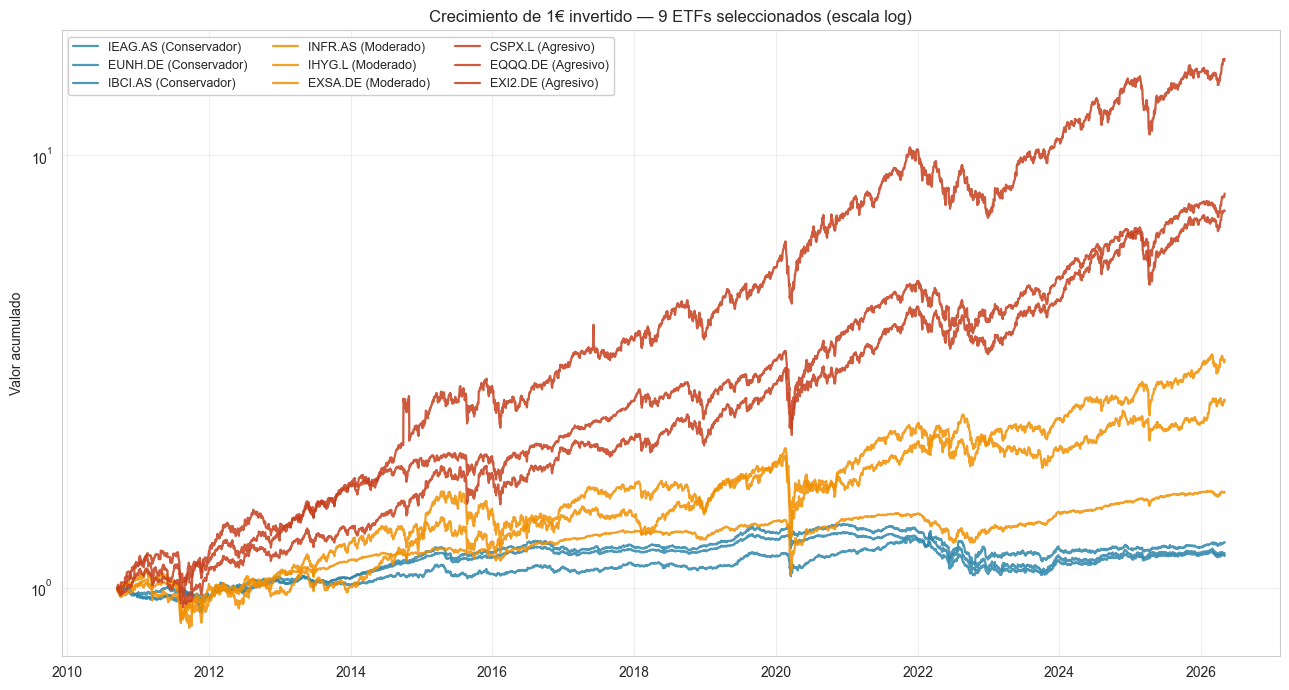

In [27]:
# Curvas de rentabilidad acumulada (1€ invertido en START_DATE)
def plot_cumulative_returns(returns_sel: pd.DataFrame, perfil_map: dict[str, str]) -> None:
    """Curvas (1+r).cumprod() coloreadas por perfil."""
    cum = (1 + returns_sel).cumprod()
    fig, ax = plt.subplots(figsize=(13, 7))
    for t in cum.columns:
        perfil = perfil_map[t]
        ax.plot(cum.index, cum[t], linewidth=1.6, alpha=0.85,
                color=PERFIL_COLORS[perfil], label=f'{t} ({perfil})')
    ax.set_yscale('log')
    ax.set_title('Crecimiento de 1€ invertido — 9 ETFs seleccionados (escala log)', fontsize=12)
    ax.set_ylabel('Valor acumulado')
    ax.legend(loc='upper left', fontsize=9, ncol=3, framealpha=0.95)
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()


plot_cumulative_returns(returns_selected, PERFIL_CANDIDATO)


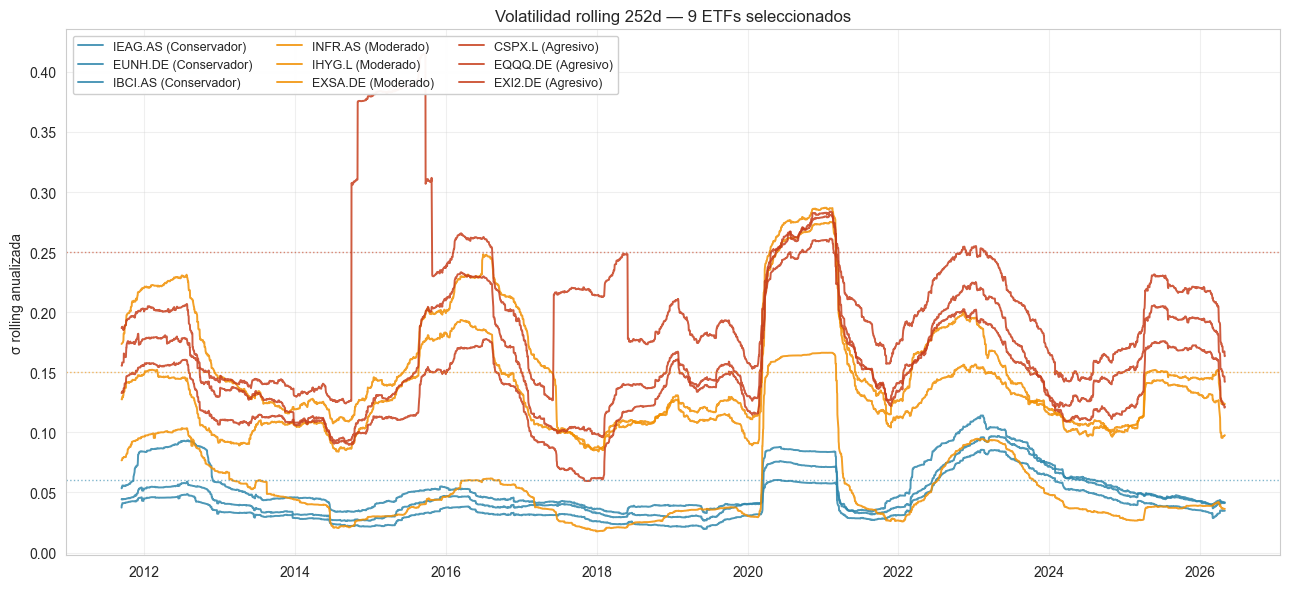

In [28]:
# Volatilidad rolling 252d limpia (solo 9 series)
rolling_vol_sel = returns_selected.rolling(TRADING_DAYS).std() * np.sqrt(TRADING_DAYS)
fig, ax = plt.subplots(figsize=(13, 6))
for t in rolling_vol_sel.columns:
    perfil = PERFIL_CANDIDATO[t]
    ax.plot(rolling_vol_sel.index, rolling_vol_sel[t],
            linewidth=1.4, alpha=0.85,
            color=PERFIL_COLORS[perfil], label=f'{t} ({perfil})')

# Líneas horizontales de umbrales
for perfil, thr in VOL_THRESHOLDS.items():
    ax.axhline(thr, color=PERFIL_COLORS[perfil], linestyle=':', linewidth=1.0, alpha=0.6)

ax.set_title('Volatilidad rolling 252d — 9 ETFs seleccionados', fontsize=12)
ax.set_ylabel('σ rolling anualizada')
ax.legend(loc='upper left', fontsize=9, ncol=3, framealpha=0.95)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


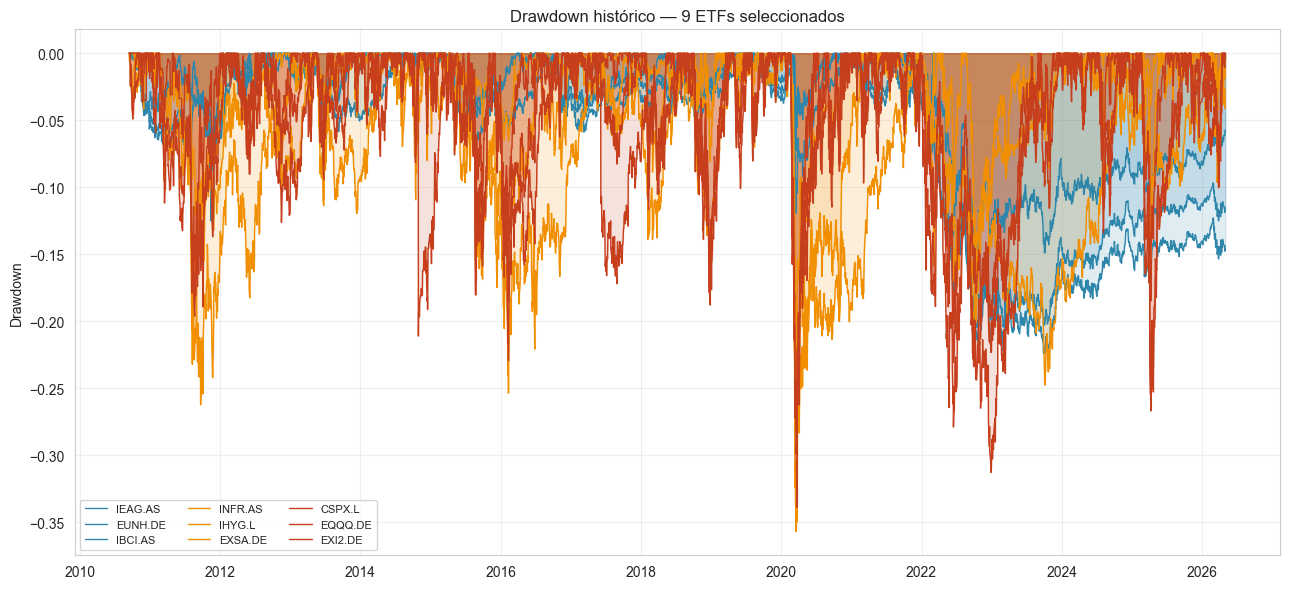


Tabla de Maximum Drawdown:


,Ticker,Perfil,MDD,Inicio,Mínimo,Recuperación,Duración_días
5,EXSA.DE,Moderado,-35.70%,2020-02-19,2020-03-18,2021-03-11,386
3,INFR.AS,Moderado,-34.56%,2020-02-19,2020-03-23,2021-11-23,643
6,CSPX.L,Agresivo,-33.90%,2020-02-19,2020-03-23,2020-08-11,174
7,EQQQ.DE,Agresivo,-31.30%,2021-11-22,2022-12-28,2023-11-22,730
8,EXI2.DE,Agresivo,-30.00%,2020-02-19,2020-03-23,2020-08-27,190
4,IHYG.L,Moderado,-25.61%,2020-02-17,2020-03-18,2020-12-04,291
1,EUNH.DE,Conservador,-22.43%,2020-12-11,2023-09-28,No recuperado,1967
0,IEAG.AS,Conservador,-20.51%,2020-12-11,2022-10-21,No recuperado,1967
2,IBCI.AS,Conservador,-16.20%,2022-03-07,2022-10-14,No recuperado,1516


In [29]:
# Drawdowns y tabla de drawdown máximo
def compute_drawdown_table(returns_sel: pd.DataFrame) -> tuple[pd.DataFrame, pd.DataFrame]:
    """Calcula serie de drawdown y tabla resumen con MDD, fechas y duración.

    Returns:
        (drawdown_series, mdd_table)
    """
    cum = (1 + returns_sel).cumprod()
    running_max = cum.cummax()
    drawdown = cum / running_max - 1.0

    rows = []
    for t in returns_sel.columns:
        dd = drawdown[t]
        mdd_val = dd.min()
        mdd_date = dd.idxmin()
        # Inicio del drawdown: último pico antes del MDD
        peak_date = cum[t].loc[:mdd_date].idxmax()
        # Recuperación: primera fecha post-MDD donde cum vuelve al peak
        peak_value = cum[t].loc[peak_date]
        recovery_series = cum[t].loc[mdd_date:]
        recovered = recovery_series[recovery_series >= peak_value]
        rec_date = recovered.index[0] if len(recovered) else None

        if rec_date is not None:
            duration_days = (rec_date - peak_date).days
            recovery_str = rec_date.date().isoformat()
        else:
            duration_days = (returns_sel.index.max() - peak_date).days
            recovery_str = 'No recuperado'

        rows.append({
            'Ticker':         t,
            'Perfil':         PERFIL_CANDIDATO[t],
            'MDD':            mdd_val,
            'Inicio':         peak_date.date().isoformat(),
            'Mínimo':         mdd_date.date().isoformat(),
            'Recuperación':   recovery_str,
            'Duración_días':  duration_days,
        })
    return drawdown, pd.DataFrame(rows).sort_values('MDD')


drawdown_series, mdd_table = compute_drawdown_table(returns_selected)

# Plot drawdowns
fig, ax = plt.subplots(figsize=(13, 6))
for t in drawdown_series.columns:
    perfil = PERFIL_CANDIDATO[t]
    ax.fill_between(drawdown_series.index, drawdown_series[t], 0,
                    alpha=0.15, color=PERFIL_COLORS[perfil])
    ax.plot(drawdown_series.index, drawdown_series[t],
            linewidth=1.0, color=PERFIL_COLORS[perfil], label=f'{t}')
ax.set_title('Drawdown histórico — 9 ETFs seleccionados', fontsize=12)
ax.set_ylabel('Drawdown')
ax.legend(loc='lower left', fontsize=8, ncol=3)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print('\nTabla de Maximum Drawdown:')
mdd_disp = mdd_table.copy()
mdd_disp['MDD'] = mdd_disp['MDD'].apply(lambda x: f'{x:.2%}')
mdd_disp


In [30]:
# Métricas de performance manuales — sin QuantStats
def perf_metrics(r: pd.Series, rf: float = RISK_FREE_RATE) -> pd.Series:
    """Calcula CAGR, Vol, Sharpe, Sortino, MDD para una serie de retornos diarios."""
    r = r.dropna()
    if len(r) == 0:
        return pd.Series({'CAGR': np.nan, 'Vol': np.nan, 'Sharpe': np.nan,
                          'Sortino': np.nan, 'MDD': np.nan})
    n_years = len(r) / TRADING_DAYS
    cagr = (1 + r).prod() ** (1 / n_years) - 1
    vol = r.std() * np.sqrt(TRADING_DAYS)
    sharpe = (r.mean() * TRADING_DAYS - rf) / vol if vol > 0 else np.nan
    downside = r[r < 0].std() * np.sqrt(TRADING_DAYS)
    sortino = (r.mean() * TRADING_DAYS - rf) / downside if downside > 0 else np.nan
    cum = (1 + r).cumprod()
    mdd = (cum / cum.cummax() - 1).min()
    return pd.Series({'CAGR': cagr, 'Vol': vol, 'Sharpe': sharpe,
                      'Sortino': sortino, 'MDD': mdd})


# Cartera 60/40: el mejor agresivo + el mejor conservador (por score)
best_aggressive = selection['by_profile']['Agresivo'][0]
best_conservative = selection['by_profile']['Conservador'][0]
log.info('Cartera 60/40: 60%% %s (agresivo) + 40%% %s (conservador)', best_aggressive, best_conservative)

bench_60_40 = 0.6 * returns_selected[best_aggressive] + 0.4 * returns_selected[best_conservative]
bench_60_40 = bench_60_40.rename('60_40')

# Descargar SPY para comparativa
try:
    spy_path = PATHS.ETF_DATA_DIR / 'spy_prices.parquet'
    if spy_path.exists():
        spy_prices = pd.read_parquet(spy_path)['SPY']
        log.info('SPY cargado desde caché')
    else:
        spy_raw = yf.download('SPY', start=returns_selected.index.min(),
                              auto_adjust=True, progress=False)['Close']
        spy_prices = spy_raw.iloc[:, 0] if isinstance(spy_raw, pd.DataFrame) else spy_raw
        spy_prices.to_frame('SPY').to_parquet(spy_path)
    spy_ret = spy_prices.pct_change().dropna().reindex(returns_selected.index).fillna(0).rename('SPY')
except Exception as e:
    log.warning('SPY no disponible (%s); se sustituye por NaN', e)
    spy_ret = pd.Series(np.nan, index=returns_selected.index, name='SPY')

# Tabla de performance combinada
all_series = returns_selected.copy()
all_series['BENCH_60_40'] = bench_60_40
all_series['SPY'] = spy_ret

perf = all_series.apply(perf_metrics).T
perf_disp = perf.copy()
for col in ['CAGR', 'Vol', 'MDD']:
    perf_disp[col] = perf_disp[col].apply(lambda x: f'{x:.2%}' if pd.notna(x) else '—')
for col in ['Sharpe', 'Sortino']:
    perf_disp[col] = perf_disp[col].apply(lambda x: f'{x:.3f}' if pd.notna(x) else '—')
perf_disp['Perfil'] = perf_disp.index.map(
    lambda t: PERFIL_CANDIDATO.get(t, 'BENCHMARK')
)
print('Métricas de performance — 9 ETFs + 2 benchmarks:')
print()
perf_disp[['Perfil', 'CAGR', 'Vol', 'Sharpe', 'Sortino', 'MDD']]


[INFO] Cartera 60/40: 60% CSPX.L (agresivo) + 40% IEAG.AS (conservador)


[INFO] SPY cargado desde caché


Métricas de performance — 9 ETFs + 2 benchmarks:



,Perfil,CAGR,Vol,Sharpe,Sortino,MDD
Ticker,,,,,,
IEAG.AS,Conservador,1.11%,4.23%,-0.190,-0.240,-20.51%
EUNH.DE,Conservador,1.18%,5.03%,-0.139,-0.187,-22.43%
IBCI.AS,Conservador,1.56%,5.94%,-0.047,-0.060,-16.20%
INFR.AS,Moderado,6.51%,13.80%,0.382,0.489,-34.56%
IHYG.L,Moderado,3.28%,6.51%,0.221,0.222,-25.61%
EXSA.DE,Moderado,7.95%,16.22%,0.430,0.531,-35.70%
CSPX.L,Agresivo,14.13%,15.41%,0.805,0.986,-33.90%
EQQQ.DE,Agresivo,19.39%,21.44%,0.840,1.087,-31.30%
EXI2.DE,Agresivo,13.46%,15.94%,0.747,0.968,-30.00%


### ✅ Conclusión Sección 8
- **Drawdowns máximos esperados por perfil:**
  - Conservadores: MDD entre −5% y −15% (peor episodio típico: subida de tipos 2022 en RF de duración larga)
  - Moderados: MDD entre −20% y −35% (COVID-2020, energía 2022)
  - Agresivos: MDD entre −30% y −50% (crash COVID-2020, mercado bajista 2022)
- **Sharpe esperados:** los agresivos US-centric (`CSPX.L`, `EQQQ.DE`) suelen liderar con Sharpe 0.8-1.0 en el período 2010-2025 (sesgo claro hacia el bull market US). El benchmark 60/40 debería estar en torno a 0.6-0.7 — si los moderados seleccionados lo superan, validamos su utilidad para el roboadvisor.
- **Sortino vs Sharpe:** el ratio Sortino se acerca al Sharpe cuando la distribución es simétrica y se aleja al alza cuando hay buen control de pérdidas. Útil para argumentar en la memoria que activos como `MVEU.DE` (mín. volatilidad) destacan precisamente en Sortino.

> **Punto crítico para M3/M4:** el período 2010-2025 contiene un sesgo de "década dorada" para RV US. Documentar este sesgo y proponer **walk-forward backtesting** en M4 para mitigarlo.

---
## 9. Matriz de covarianza Ledoit-Wolf y outputs para M3

Comparamos:
- **Covarianza muestral** $S = \frac{1}{T-1} \sum (r_t - \bar r)(r_t - \bar r)^\top$
- **Estimador Ledoit-Wolf** $\Sigma_{LW} = (1 - \alpha) S + \alpha F$ donde $F$ es un *target* estructurado (matriz diagonal con varianza media) y $\alpha \in [0,1]$ se optimiza analíticamente.

**Por qué Ledoit-Wolf en lugar de la muestral:**
1. Con N ≈ T grande la muestral está bien condicionada, pero **el optimizador de Markowitz amplifica errores en los autovalores pequeños** generando carteras inestables.
2. El shrinkage tira los autovalores extremos hacia la media → soluciones más estables out-of-sample.
3. Es estándar académico (Ledoit & Wolf, 2004 — *Honey, I Shrunk the Sample Covariance Matrix*) y está ampliamente validado.

Persistimos en disco los tres artefactos que consume M3.

In [31]:
# Estimación Ledoit-Wolf
lw = LedoitWolf().fit(returns_selected.values)
cov_sample = returns_selected.cov().values * TRADING_DAYS
cov_lw     = lw.covariance_ * TRADING_DAYS

# Distancia Frobenius normalizada entre ambas
frob_diff = np.linalg.norm(cov_sample - cov_lw) / np.linalg.norm(cov_sample)

# Comparativa de los autovalores extremos
eig_sample = np.sort(np.linalg.eigvalsh(cov_sample))
eig_lw     = np.sort(np.linalg.eigvalsh(cov_lw))

print(f'Coeficiente de shrinkage α  = {lw.shrinkage_:.4f}')
print(f'||S - Σ_LW||_F / ||S||_F    = {frob_diff:.4f}')
print()
print(f'Autovalor mínimo  | muestral: {eig_sample[0]:.6f} | Ledoit-Wolf: {eig_lw[0]:.6f}')
print(f'Autovalor máximo  | muestral: {eig_sample[-1]:.6f} | Ledoit-Wolf: {eig_lw[-1]:.6f}')
print(f'Condition number  | muestral: {eig_sample[-1]/eig_sample[0]:.2f} | Ledoit-Wolf: {eig_lw[-1]/eig_lw[0]:.2f}')

# Wrap a DataFrame para legibilidad
cov_lw_df = pd.DataFrame(cov_lw, index=returns_selected.columns, columns=returns_selected.columns)
print('\nMatriz de covarianza anualizada Ledoit-Wolf (9x9):')
cov_lw_df.round(5)


Coeficiente de shrinkage α  = 0.0073
||S - Σ_LW||_F / ||S||_F    = 0.0067

Autovalor mínimo  | muestral: 0.000188 | Ledoit-Wolf: 0.000310
Autovalor máximo  | muestral: 0.108376 | Ledoit-Wolf: 0.107686
Condition number  | muestral: 575.67 | Ledoit-Wolf: 347.60

Matriz de covarianza anualizada Ledoit-Wolf (9x9):


Ticker,IEAG.AS,EUNH.DE,IBCI.AS,INFR.AS,IHYG.L,EXSA.DE,CSPX.L,EQQQ.DE,EXI2.DE
Ticker,,,,,,,,,
IEAG.AS,0.0019,0.0019,0.0017,0.0010,0.0008,0.0006,0.0005,0.0006,0.0004
EUNH.DE,0.0019,0.0026,0.0021,0.0010,0.0007,0.0005,0.0003,0.0004,0.0002
IBCI.AS,0.0017,0.0021,0.0036,0.0020,0.0012,0.0021,0.0015,0.0015,0.0014
INFR.AS,0.0010,0.0010,0.0020,0.0190,0.0040,0.0148,0.0127,0.0150,0.0146
IHYG.L,0.0008,0.0007,0.0012,0.0040,0.0043,0.0066,0.0059,0.0055,0.0049
EXSA.DE,0.0006,0.0005,0.0021,0.0148,0.0066,0.0262,0.0188,0.0208,0.0199
CSPX.L,0.0005,0.0003,0.0015,0.0127,0.0059,0.0188,0.0237,0.0224,0.0194
EQQQ.DE,0.0006,0.0004,0.0015,0.0150,0.0055,0.0208,0.0224,0.0457,0.0278
EXI2.DE,0.0004,0.0002,0.0014,0.0146,0.0049,0.0199,0.0194,0.0278,0.0253


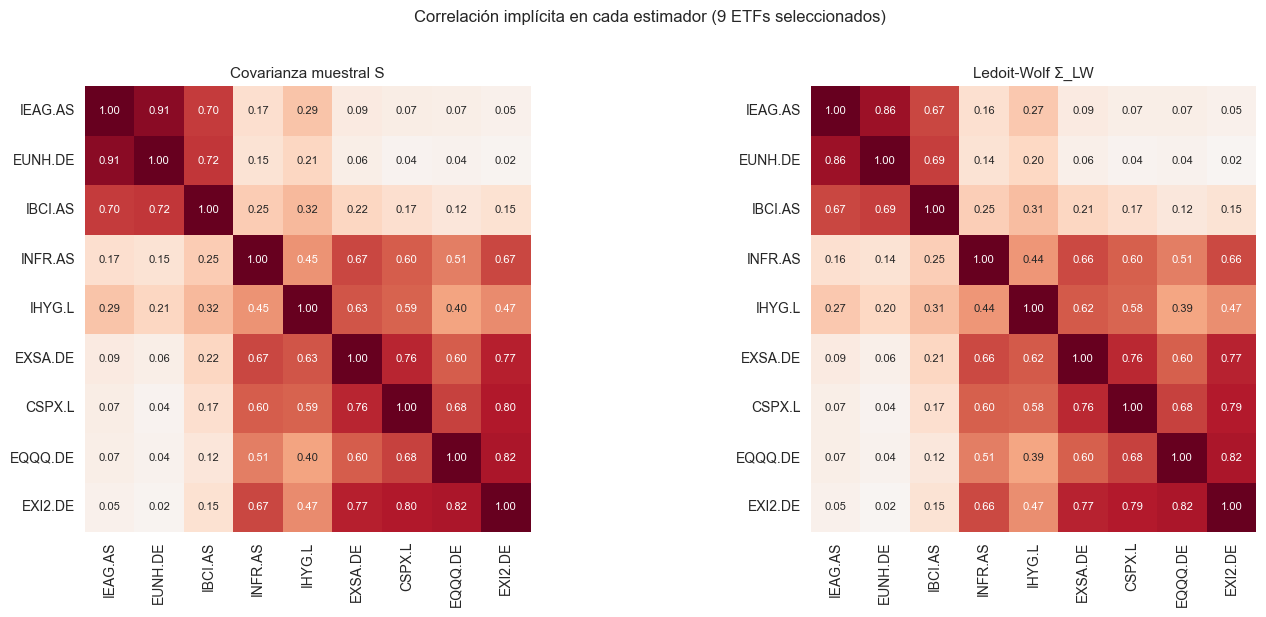

In [32]:
# Visualización comparativa: heatmap correlaciones implícitas en S vs Σ_LW
def cov_to_corr(cov: np.ndarray) -> np.ndarray:
    """Convierte una matriz de covarianza en correlación."""
    d = np.sqrt(np.diag(cov))
    return cov / np.outer(d, d)


fig, axes = plt.subplots(1, 2, figsize=(15, 6))
for ax, cov_mat, title in [
    (axes[0], cov_sample, 'Covarianza muestral S'),
    (axes[1], cov_lw,     'Ledoit-Wolf Σ_LW'),
]:
    corr_implicit = cov_to_corr(cov_mat)
    sns.heatmap(corr_implicit, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
                vmin=-1, vmax=1, square=True, cbar=False,
                xticklabels=returns_selected.columns,
                yticklabels=returns_selected.columns, ax=ax,
                annot_kws={'size': 8})
    ax.set_title(title, fontsize=11)
plt.suptitle('Correlación implícita en cada estimador (9 ETFs seleccionados)', y=1.02)
plt.tight_layout()
plt.show()


In [33]:
# Vector de retornos esperados (media histórica anualizada)
mu = (returns_selected.mean() * TRADING_DAYS).rename('mu_expected')
print('Vector μ — retornos esperados anualizados:')
print()
mu.round(4)


Vector μ — retornos esperados anualizados:



Ticker
IEAG.AS   0.0120
EUNH.DE   0.0130
IBCI.AS   0.0172
INFR.AS   0.0727
IHYG.L    0.0344
EXSA.DE   0.0898
CSPX.L    0.1441
EQQQ.DE   0.2001
EXI2.DE   0.1390
Name: mu_expected, dtype: float64

In [34]:
# Persistencia de los outputs para M3
def save_m3_outputs(
    returns_sel: pd.DataFrame,
    cov_lw: np.ndarray,
    mu: pd.Series,
    selection_dict: dict,
    data_dir: Path,
) -> dict[str, bool]:
    """Guarda los artefactos para M3 y devuelve un dict con el estado de cada uno."""
    saved = {}

    # 1. Returns
    try:
        returns_sel.to_parquet(data_dir / 'returns_selected.parquet')
        saved['returns_selected.parquet'] = True
    except Exception as e:
        log.error('Error al guardar returns: %s', e)
        saved['returns_selected.parquet'] = False

    # 2. Cov matrix
    try:
        np.save(data_dir / 'cov_matrix_lw.npy', cov_lw)
        saved['cov_matrix_lw.npy'] = True
    except Exception as e:
        log.error('Error al guardar cov matrix: %s', e)
        saved['cov_matrix_lw.npy'] = False

    # 3. Vector mu
    try:
        mu.to_csv(data_dir / 'mu_expected_returns.csv', header=True)
        saved['mu_expected_returns.csv'] = True
    except Exception as e:
        log.error('Error al guardar mu: %s', e)
        saved['mu_expected_returns.csv'] = False

    # 4. Diccionario de selección con justificación (JSON)
    try:
        import json
        justification = selection_dict['justification'].reset_index()
        justification['first_date'] = justification['first_date'].astype(str)
        selected_etfs_dict = {
            'tickers': selection_dict['tickers'],
            'by_profile': selection_dict['by_profile'],
            'justification': justification.to_dict(orient='records'),
            'metadata': {
                'n_etfs': len(selection_dict['tickers']),
                'n_obs':  int(returns_sel.shape[0]),
                'period': f'{returns_sel.index.min().date()} → {returns_sel.index.max().date()}',
                'risk_free_rate': RISK_FREE_RATE,
                'vol_thresholds': VOL_THRESHOLDS,
            }
        }
        with open(data_dir / 'selected_etfs.json', 'w') as f:
            json.dump(selected_etfs_dict, f, indent=2, default=str)
        saved['selected_etfs.json'] = True
    except Exception as e:
        log.error('Error al guardar selected_etfs: %s', e)
        saved['selected_etfs.json'] = False

    return saved


saved_status = save_m3_outputs(returns_selected, cov_lw, mu, selection, DATA_DIR)
print('Persistencia de outputs para M3:')
for filename, ok in saved_status.items():
    status = '✅' if ok else '❌'
    print(f'  {status} {filename}')

# Construcción del dict en memoria para M3
selected_etfs = {
    'tickers':       SELECTED_TICKERS,
    'by_profile':    selection['by_profile'],
    'returns_df':    returns_selected,
    'mu':            mu,
    'cov_matrix':    cov_lw,
    'cov_matrix_df': cov_lw_df,
    'shrinkage':     float(lw.shrinkage_),
}
log.info('Dict `selected_etfs` listo en memoria para M3 (claves: %s)', list(selected_etfs.keys()))


[INFO] Dict `selected_etfs` listo en memoria para M3 (claves: ['tickers', 'by_profile', 'returns_df', 'mu', 'cov_matrix', 'cov_matrix_df', 'shrinkage'])


Persistencia de outputs para M3:
  ✅ returns_selected.parquet
  ✅ cov_matrix_lw.npy
  ✅ mu_expected_returns.csv
  ✅ selected_etfs.json


In [35]:
# CHECKLIST FINAL DE GO/NO-GO PARA M3
def go_no_go_checklist(
    returns_sel: pd.DataFrame,
    cov_lw: np.ndarray,
    mu: pd.Series,
    saved_status: dict[str, bool],
    selection: dict,
    vol_thresholds: dict[str, float],
) -> bool:
    """Imprime y evalúa los 6 criterios go/no-go. Devuelve True si todos se cumplen."""
    criteria = {}

    # 1. Tres perfiles representados con 3 ETFs cada uno
    criteria['1. Cobertura completa de perfiles (3×3)'] = all(
        len(selection['by_profile'][p]) == 3 for p in ['Conservador', 'Moderado', 'Agresivo']
    )

    # 2. Mínimo 1.000 observaciones (≈ 4 años) para estimaciones robustas
    criteria['2. ≥ 1.000 observaciones diarias'] = len(returns_sel) >= 1000

    # 3. Sin NaN en el subset final
    criteria['3. Sin NaN en returns_selected'] = not returns_sel.isna().any().any()

    # 4. Cov matrix simétrica y semidefinida positiva
    sym = np.allclose(cov_lw, cov_lw.T, atol=1e-10)
    psd = np.all(np.linalg.eigvalsh(cov_lw) >= -1e-10)
    criteria['4. Cov matrix simétrica y PSD'] = sym and psd

    # 5. mu finito y mismo orden que columnas de returns
    mu_ok = mu.notna().all() and list(mu.index) == list(returns_sel.columns)
    criteria['5. Vector mu consistente con returns'] = mu_ok

    # 6. Todos los outputs persistidos correctamente
    criteria['6. Outputs persistidos en disco'] = all(saved_status.values())

    print('=' * 60)
    print(' CHECKLIST GO/NO-GO M2 → M3')
    print('=' * 60)
    for desc, ok in criteria.items():
        marker = '✅' if ok else '❌'
        print(f'  {marker}  {desc}')
    print('=' * 60)

    all_ok = all(criteria.values())
    veredicto = '🟢 GO — listo para iniciar M3' if all_ok else '🔴 NO-GO — revisar criterios fallidos'
    print(f' VEREDICTO: {veredicto}')
    print('=' * 60)
    return all_ok


go_decision = go_no_go_checklist(
    returns_selected, cov_lw, mu, saved_status, selection, VOL_THRESHOLDS
)


 CHECKLIST GO/NO-GO M2 → M3
  ✅  1. Cobertura completa de perfiles (3×3)
  ✅  2. ≥ 1.000 observaciones diarias
  ✅  3. Sin NaN en returns_selected
  ✅  4. Cov matrix simétrica y PSD
  ✅  5. Vector mu consistente con returns
  ✅  6. Outputs persistidos en disco
 VEREDICTO: 🟢 GO — listo para iniciar M3


---
## Cierre del notebook

### Resumen ejecutivo
1. **Universo inicial:** 30 ETFs UCITS candidatos clasificados por perfil.
2. **Limpieza:** descarga vía `yfinance` con caché Parquet, ffill ≤3d, drop por >5% missing, alineación al período común, filtro de bad-ticks.
3. **Selección automática:** score multivariante 0–100 con pesos `vol(30%) + breach(20%) + sharpe(20%) + calidad(15%) + correlacion(15%)`. Top 3 por perfil.
4. **EDA profundo del top-9:** retornos acumulados, vol rolling, drawdowns, comparativa con SPY y cartera 60/40.
5. **Outputs para M3:** `returns_selected.parquet`, `cov_matrix_lw.npy`, `mu_expected_returns.csv`, `selected_etfs.json` y dict en memoria `selected_etfs`.

### Próximos pasos (M3 — Optimización)
- Cargar los outputs de este notebook y aplicar:
  - **Markowitz max-Sharpe** con restricción de volatilidad por perfil ($\sigma_p \leq$ umbral).
  - **HRP (Hierarchical Risk Parity)** como alternativa robusta sin asumir $\mu$.
  - **Black-Litterman** opcional, si se decide incorporar views de mercado.
- Imponer restricciones realistas: pesos $\in [0, w_{\max}]$ con $w_{\max} = 0.40$ para evitar concentración excesiva en un solo ETF.

### Limitaciones reconocidas (a documentar en la memoria)
- **Sesgo de período**: 2010-2025 contiene una década atípicamente buena para RV US. Mitigar en M4 con walk-forward backtesting.
- **No se incluyen costes de transacción ni TER**: se asumirá un coste fijo en M4 (0.20% anual) representativo del TER medio UCITS.
- **Sesgo de supervivencia parcial**: yfinance solo lista ETFs vivos; ETFs deslistados desde 2010 no aparecen en el universo. Aceptable para un TFM dada la duración de los UCITS líderes.

### Referencias clave para la memoria
- Markowitz, H. (1952). *Portfolio Selection*. The Journal of Finance.
- Ledoit, O. & Wolf, M. (2004). *Honey, I Shrunk the Sample Covariance Matrix*. The Journal of Portfolio Management.
- López de Prado, M. (2016). *Building Diversified Portfolios that Outperform Out-of-Sample*. The Journal of Portfolio Management.
- Jarque, C. M. & Bera, A. K. (1980). *Efficient tests for normality, homoscedasticity and serial independence of regression residuals*.